In [ ]:

"""
================================================================================
  APPLE INC. (AAPL) -- EQUITY VALUATION MODEL
  Discounted Cash Flow + Relative Valuation + KPI Diagnostics
================================================================================

  WHAT THIS SCRIPT DOES
  ---------------------
  This is a single-file, end-to-end equity research model built to run inside
  Google Colab (or any Jupyter/Python 3.9+ environment). It:

    1. Pulls Apple's audited financial statements and live market data (yfinance)
    2. Computes a full panel of fundamental KPIs and grades each one
    3. Builds a 5-year unlevered Free Cash Flow forecast
    4. Discounts those cash flows to a per-share intrinsic value (DCF)
    5. Cross-checks that value against trading comparables (MSFT/NVDA/AMZN/GOOGL)
    6. Stress-tests the answer across a WACC x terminal-growth grid
    7. Renders seven analyst-grade charts
    8. Writes a bull / base / bear investment summary with a rating

  HOW TO USE IT
  -------------
    - Scroll to the "USER ASSUMPTIONS" block below. Every input you can change
      lives there, one variable per line. Nothing else needs editing.
    - Run the file top to bottom. In Colab:  %run aapl_valuation_model.py
      or simply paste the whole file into one cell and press Shift+Enter.

  A NOTE ON WHAT A DCF ACTUALLY IS
  --------------------------------
  A DCF says: a company is worth the cash it will hand its owners over its life,
  discounted back to today because a dollar in 2031 is worth less than a dollar
  now. Everything below is bookkeeping around that one sentence. The output is
  only as good as the assumptions you feed it -- the model does not know the
  future, it only makes your view of the future arithmetically explicit.

  DISCLAIMER
  ----------
  Educational tool. Estimates, not investment advice. Do your own research and
  speak to a licensed financial professional before making decisions.

================================================================================
"""

'\n================================================================================\n  APPLE INC. (AAPL) -- EQUITY VALUATION MODEL\n  Discounted Cash Flow + Relative Valuation + KPI Diagnostics\n================================================================================\n \n  WHAT THIS SCRIPT DOES\n  ---------------------\n  This is a single-file, end-to-end equity research model built to run inside\n  Google Colab (or any Jupyter/Python 3.9+ environment). It:\n \n    1. Pulls Apple\'s audited financial statements and live market data (yfinance)\n    2. Computes a full panel of fundamental KPIs and grades each one\n    3. Builds a 5-year unlevered Free Cash Flow forecast\n    4. Discounts those cash flows to a per-share intrinsic value (DCF)\n    5. Cross-checks that value against trading comparables (MSFT/NVDA/AMZN/GOOGL)\n    6. Stress-tests the answer across a WACC x terminal-growth grid\n    7. Renders seven analyst-grade charts\n    8. Writes a bull / base / bear investment s

In [ ]:
# =============================================================================
#  CELL 1 -- PACKAGE INSTALLATION
# =============================================================================
# Colab ships with pandas/numpy/matplotlib/seaborn/scipy already installed, but
# yfinance and tabulate usually are not. We install quietly and only if needed,
# so re-running the notebook does not waste 30 seconds on pip every time.

import importlib
import subprocess
import sys

# Set to False if you manage your own environment and don't want pip to run.
AUTO_INSTALL_PACKAGES = True

# (import_name, pip_install_spec)
_REQUIRED_PACKAGES = [
    ("yfinance",   "yfinance>=0.2.40"),
    ("pandas",     "pandas"),
    ("numpy",      "numpy"),
    ("matplotlib", "matplotlib"),
    ("seaborn",    "seaborn"),
    ("scipy",      "scipy"),
    ("tabulate",   "tabulate"),
]


def _ensure_packages() -> None:
    """Install any missing third-party package, quietly."""
    for import_name, pip_spec in _REQUIRED_PACKAGES:
        try:
            importlib.import_module(import_name)
        except ImportError:
            print(f"[setup] Installing {pip_spec} ...")
            subprocess.check_call(
                [sys.executable, "-m", "pip", "install", "-q", pip_spec]
            )


# Detect Colab so we can tailor a couple of display behaviours later on.
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if AUTO_INSTALL_PACKAGES:
    _ensure_packages()

In [ ]:
# =============================================================================
#  CELL 2 -- IMPORTS AND GLOBAL DISPLAY CONFIGURATION
# =============================================================================

import warnings
from dataclasses import dataclass, field
from datetime import datetime
from typing import Dict, List, Optional, Sequence, Tuple

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
import yfinance as yf
from scipy import stats
from tabulate import tabulate

# yfinance is chatty about deprecated pandas idioms and occasional 404s on
# statement rows. None of that is actionable for the user, so we mute it.
warnings.filterwarnings("ignore")

# Make DataFrames readable in a notebook: no scientific notation, wide console.
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 220)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

# Consistent, print-friendly chart styling across all seven figures.
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.figsize":   (11, 5.5),
    "figure.dpi":       110,
    "axes.titlesize":   13,
    "axes.titleweight": "bold",
    "axes.labelsize":   11,
    "axes.edgecolor":   "#444444",
    "grid.alpha":       0.30,
    "font.family":      "DejaVu Sans",
})

# House colour palette -- one place to restyle every chart.
COLOR_PRIMARY   = "#0B5FFF"   # Apple-ish blue, used for headline series
COLOR_SECONDARY = "#FF8A00"   # amber, used for the comparison series
COLOR_POSITIVE  = "#1B9E4B"   # green
COLOR_NEGATIVE  = "#D62828"   # red
COLOR_NEUTRAL   = "#8A8A8A"   # grey


# #############################################################################
# #                                                                           #
# #                        U S E R   A S S U M P T I O N S                    #
# #                                                                           #
# #   Everything you are meant to change lives between here and the next      #
# #   banner. One variable per assumption. Rates are decimals: 0.08 = 8%.     #
# #                                                                           #
# #############################################################################

# -----------------------------------------------------------------------------
#  A. UNIVERSE -- what we are valuing and what we are comparing it against
# -----------------------------------------------------------------------------
TICKER = "AAPL"                                  # The subject company
PEER_TICKERS = ["MSFT", "NVDA", "AMZN", "GOOGL"] # Comparable set for multiples

# -----------------------------------------------------------------------------
#  B. REVENUE GROWTH -- Years 1 through 5, one variable each
# -----------------------------------------------------------------------------
# Apple is a mature mega-cap: mid-single-digit growth with an iPhone upgrade
# cycle and Services compounding faster than Products. Adjust to your own view.
REVENUE_GROWTH_Y1 = 0.080   #  8.0% -- year 1
REVENUE_GROWTH_Y2 = 0.070   #  7.0% -- year 2
REVENUE_GROWTH_Y3 = 0.060   #  6.0% -- year 3
REVENUE_GROWTH_Y4 = 0.050   #  5.0% -- year 4
REVENUE_GROWTH_Y5 = 0.045   #  4.5% -- year 5

# -----------------------------------------------------------------------------
#  C. TERMINAL VALUE -- what the business is worth after year 5
# -----------------------------------------------------------------------------
# Terminal growth must be BELOW your discount rate and should not exceed
# long-run nominal GDP (~2-3%). A company growing faster than the economy
# forever would eventually become the entire economy.
TERMINAL_GROWTH_RATE = 0.030   # 3.0% perpetual growth

# Which terminal method to use: "gordon", "exit_multiple", or "blend"
# "blend" averages the two, which is what most sell-side models publish.
TERMINAL_METHOD = "blend"

# Exit multiple approach: what would an acquirer pay for year-5 EBITDA?
EXIT_EV_EBITDA_MULTIPLE = 22.0

# -----------------------------------------------------------------------------
#  D. DISCOUNT RATE (WACC)
# -----------------------------------------------------------------------------
# The blended annual return debt and equity holders require. Higher WACC =
# lower valuation. Set AUTO_ESTIMATE_WACC = True to derive it via CAPM from
# Apple's live beta instead of using the hard-coded number.
DISCOUNT_RATE_WACC = 0.085     # 8.5%

AUTO_ESTIMATE_WACC = False     # If True, overrides DISCOUNT_RATE_WACC via CAPM
RISK_FREE_RATE     = 0.042     # 10-year US Treasury yield
EQUITY_RISK_PREMIUM = 0.050    # Equity premium over the risk-free rate
COST_OF_DEBT       = 0.045     # Pre-tax borrowing cost on Apple's notes

# -----------------------------------------------------------------------------
#  E. PROFITABILITY AND CASH CONVERSION
# -----------------------------------------------------------------------------
OPERATING_MARGIN     = 0.315   # 31.5% EBIT margin held flat across the forecast
EFFECTIVE_TAX_RATE   = 0.160   # 16.0% cash tax rate
CAPEX_PCT_REVENUE    = 0.035   #  3.5% of revenue spent on capital expenditure
DEPRECIATION_PCT_REVENUE = 0.035  # 3.5% of revenue in D&A (non-cash, added back)

# Working capital: modelled as a percentage of the CHANGE in revenue, not of
# total revenue. Growth consumes cash (inventory, receivables); shrinkage
# releases it. Apple runs negative working capital -- suppliers finance it --
# so a small negative number here is defensible.
WORKING_CAPITAL_PCT_OF_REVENUE_CHANGE = 0.020   # 2.0% of incremental revenue

# -----------------------------------------------------------------------------
#  F. SHARE COUNT
# -----------------------------------------------------------------------------
# NEGATIVE = net buybacks shrinking the share count (Apple's long-standing
# policy). POSITIVE = dilution from stock-based compensation.
SHARE_DILUTION_RATE = -0.025   # -2.5% per year, i.e. 2.5% net repurchase

# -----------------------------------------------------------------------------
#  G. MODEL MECHANICS
# -----------------------------------------------------------------------------
FORECAST_YEARS = 5             # Explicit forecast horizon before terminal value

# Mid-year convention discounts cash flows from the middle of each year rather
# than the end, since companies generate cash continuously. It lifts the
# valuation by roughly half a year of discounting and is standard practice.
USE_MIDYEAR_CONVENTION = True

# Margin-of-safety threshold used by the rating engine. 0.25 means you want the
# stock 25% below intrinsic value before it earns a BUY.
REQUIRED_MARGIN_OF_SAFETY = 0.25

# -----------------------------------------------------------------------------
#  H. SENSITIVITY GRID
# -----------------------------------------------------------------------------
SENSITIVITY_WACC_MIN  = 0.07   # Rows:    7% ...
SENSITIVITY_WACC_MAX  = 0.12   #          ... 12%
SENSITIVITY_WACC_STEP = 0.01

SENSITIVITY_TG_MIN    = 0.02   # Columns: 2% ...
SENSITIVITY_TG_MAX    = 0.05   #          ... 5%
SENSITIVITY_TG_STEP   = 0.005

# -----------------------------------------------------------------------------
#  I. SCENARIO DEFINITIONS -- bull and bear cases
# -----------------------------------------------------------------------------
# Expressed as deltas applied on top of the base case above, so you only tune
# the base case and the scenarios move with it.
BULL_GROWTH_UPLIFT   =  0.030   # +3.0pp added to every forecast-year growth rate
BULL_MARGIN_UPLIFT   =  0.020   # +2.0pp on operating margin
BULL_WACC_DELTA      = -0.010   # -1.0pp on WACC (lower perceived risk)

BEAR_GROWTH_HAIRCUT  = -0.040   # -4.0pp off every growth rate
BEAR_MARGIN_HAIRCUT  = -0.035   # -3.5pp off operating margin
BEAR_WACC_DELTA      =  0.015   # +1.5pp on WACC (higher perceived risk)

# -----------------------------------------------------------------------------
#  J. OUTPUT TOGGLES
# -----------------------------------------------------------------------------
SHOW_CHARTS = True             # Set False for a text-only run
PRICE_HISTORY_PERIOD = "5y"    # Lookback for the stock price chart

# #############################################################################
# #                                                                           #
# #                 E N D   O F   U S E R   A S S U M P T I O N S             #
# #        Nothing below this line needs to be edited to run the model.       #
# #                                                                           #
# #############################################################################

In [ ]:
# =============================================================================
#  CELL 3 -- SMALL UTILITIES
# =============================================================================
# yfinance returns messy, inconsistent data: row labels change between API
# versions, statements arrive newest-column-first, and any field can be absent.
# These helpers absorb that mess so the modelling code stays readable.

# Scale constants for human-readable printing.
BILLION = 1_000_000_000
MILLION = 1_000_000


def is_valid(value) -> bool:
    """True only if `value` is a real, finite, usable number."""
    if value is None:
        return False
    try:
        f = float(value)
    except (TypeError, ValueError):
        return False
    return not (np.isnan(f) or np.isinf(f))


def safe_div(numerator, denominator, default=np.nan) -> float:
    """Divide without ever raising ZeroDivisionError or propagating junk."""
    if not is_valid(numerator) or not is_valid(denominator):
        return default
    if float(denominator) == 0.0:
        return default
    return float(numerator) / float(denominator)


def fmt_money(value, unit: str = "B", decimals: int = 2) -> str:
    """Format a raw dollar figure as $123.45B / $123.45M, or 'n/a'."""
    if not is_valid(value):
        return "n/a"
    divisor = BILLION if unit == "B" else MILLION
    scaled = value / divisor
    sign = "-" if scaled < 0 else ""
    return f"{sign}${abs(scaled):,.{decimals}f}{unit}"


def fmt_pct(value, decimals: int = 1) -> str:
    """Format a decimal fraction as a percentage string. 0.315 -> '31.5%'."""
    if not is_valid(value):
        return "n/a"
    return f"{value * 100:,.{decimals}f}%"


def fmt_x(value, decimals: int = 1) -> str:
    """Format a ratio as a multiple. 22.4 -> '22.4x'."""
    if not is_valid(value):
        return "n/a"
    return f"{value:,.{decimals}f}x"


def fmt_price(value) -> str:
    """Format a per-share dollar amount. Negatives render as -$12.34."""
    if not is_valid(value):
        return "n/a"
    sign = "-" if value < 0 else ""
    return f"{sign}${abs(value):,.2f}"


def fmt_upside(value) -> str:
    """Render a signed return with the correct word: '12.0% upside' / '8.0% downside'."""
    if not is_valid(value):
        return "n/a"
    word = "upside" if value >= 0 else "downside"
    return f"{abs(value) * 100:,.1f}% {word}"


def banner(title: str, char: str = "=", width: int = 80) -> None:
    """Print a centred section header. Used to structure the console report."""
    print()
    print(char * width)
    print(f" {title}".upper())
    print(char * width)


def subheader(title: str, width: int = 80) -> None:
    """Print a lighter-weight sub-section header."""
    print()
    print(f"--- {title} " + "-" * max(0, width - len(title) - 5))


def cagr(first_value: float, last_value: float, periods: int) -> float:
    """
    Compound annual growth rate between two points.

    Returns NaN when the maths is undefined -- a negative starting value or a
    zero-length window makes CAGR meaningless rather than merely awkward.
    """
    if not is_valid(first_value) or not is_valid(last_value):
        return np.nan
    if first_value <= 0 or periods <= 0:
        return np.nan
    return (last_value / first_value) ** (1.0 / periods) - 1.0


def trend_slope(series: Sequence[float]) -> float:
    """
    Fit a least-squares line through a short series and return its slope.

    Used to decide whether a margin is expanding or compressing over time
    rather than judging it on the latest year alone, which is noisy. scipy's
    linregress is overkill for four points but it is the right tool and it
    keeps the intent obvious.
    """
    clean = [float(v) for v in series if is_valid(v)]
    if len(clean) < 2:
        return np.nan
    x = np.arange(len(clean), dtype=float)
    result = stats.linregress(x, np.array(clean, dtype=float))
    return float(result.slope)

In [ ]:
# =============================================================================
#  CELL 4 -- DATA COLLECTION LAYER
# =============================================================================
# Financial statement row labels are not stable across yfinance versions or
# across companies. "Total Revenue" may appear as "Revenue" or
# "Operating Revenue". Rather than hard-coding one label and crashing when it
# moves, we search the statement index for the first candidate that matches.

# Canonical line item -> ordered list of labels yfinance might use for it.
# Order matters: the first match wins, so put the most precise label first.
ROW_ALIASES: Dict[str, List[str]] = {
    # ---- Income statement ----
    "revenue": [
        "Total Revenue", "Revenue", "Operating Revenue",
    ],
    "cost_of_revenue": [
        "Cost Of Revenue", "Cost of Revenue", "Reconciled Cost Of Revenue",
    ],
    "gross_profit": [
        "Gross Profit",
    ],
    "operating_income": [
        "Operating Income", "Total Operating Income As Reported", "EBIT",
    ],
    "ebitda": [
        "EBITDA", "Normalized EBITDA",
    ],
    "pretax_income": [
        "Pretax Income", "Income Before Tax",
    ],
    "tax_provision": [
        "Tax Provision", "Income Tax Expense",
    ],
    "net_income": [
        "Net Income", "Net Income Common Stockholders",
        "Net Income From Continuing Operation Net Minority Interest",
        "Net Income Continuous Operations",
    ],
    "interest_expense": [
        "Interest Expense", "Interest Expense Non Operating",
        "Net Interest Income",
    ],
    "diluted_eps": [
        "Diluted EPS", "Basic EPS",
    ],
    "diluted_shares": [
        "Diluted Average Shares", "Basic Average Shares",
    ],
    "rnd": [
        "Research And Development",
    ],
    # ---- Balance sheet ----
    "cash": [
        "Cash Cash Equivalents And Short Term Investments",
        "Cash And Cash Equivalents",
        "Cash Financial",
    ],
    "total_debt": [
        "Total Debt",
    ],
    "long_term_debt": [
        "Long Term Debt", "Long Term Debt And Capital Lease Obligation",
    ],
    "short_term_debt": [
        "Current Debt", "Current Debt And Capital Lease Obligation",
        "Short Long Term Debt",
    ],
    "total_equity": [
        "Stockholders Equity", "Total Equity Gross Minority Interest",
        "Common Stock Equity",
    ],
    "total_assets": [
        "Total Assets",
    ],
    "current_assets": [
        "Current Assets", "Total Current Assets",
    ],
    "current_liabilities": [
        "Current Liabilities", "Total Current Liabilities",
    ],
    "invested_capital": [
        "Invested Capital",
    ],
    "shares_issued": [
        "Share Issued", "Ordinary Shares Number",
    ],
    # ---- Cash flow statement ----
    "operating_cash_flow": [
        "Operating Cash Flow", "Total Cash From Operating Activities",
        "Cash Flow From Continuing Operating Activities",
    ],
    "capex": [
        "Capital Expenditure", "Capital Expenditures",
        "Net PPE Purchase And Sale", "Purchase Of PPE",
    ],
    "free_cash_flow": [
        "Free Cash Flow",
    ],
    "depreciation": [
        "Depreciation And Amortization",
        "Depreciation Amortization Depletion",
        "Depreciation",
        "Reconciled Depreciation",
    ],
    "buybacks": [
        "Repurchase Of Capital Stock", "Repurchase Of Common Stock",
    ],
    "dividends_paid": [
        "Cash Dividends Paid", "Common Stock Dividend Paid",
    ],
}


def find_row(statement: Optional[pd.DataFrame], item_key: str) -> Optional[pd.Series]:
    """
    Pull one canonical line item out of a yfinance statement DataFrame.

    Returns a Series indexed by period (oldest first) or None if no alias
    matched. Matching is case-insensitive and ignores spaces, so
    "Cost of Revenue" and "Cost Of Revenue" both resolve.
    """
    if statement is None or statement.empty:
        return None

    aliases = ROW_ALIASES.get(item_key, [item_key])

    # Build a normalised lookup: "totalrevenue" -> the actual index label.
    normalised = {
        str(label).lower().replace(" ", ""): label
        for label in statement.index
    }

    for alias in aliases:
        key = alias.lower().replace(" ", "")
        if key in normalised:
            row = statement.loc[normalised[key]]
            # A statement can contain duplicate labels; take the first.
            if isinstance(row, pd.DataFrame):
                row = row.iloc[0]
            # yfinance returns newest period first. Reverse for time-series work.
            return pd.to_numeric(row, errors="coerce").sort_index()

    return None


def latest_value(statement: Optional[pd.DataFrame], item_key: str) -> float:
    """Most recent reported value for a line item, or NaN."""
    row = find_row(statement, item_key)
    if row is None or row.dropna().empty:
        return np.nan
    return float(row.dropna().iloc[-1])


@dataclass
class CompanyData:
    """
    Everything the model knows about one company, in one tidy container.

    Using a dataclass instead of a loose dict means typos become AttributeErrors
    at the point of the mistake, rather than silent NaNs three functions later.
    """
    ticker: str
    name: str = ""

    # --- Raw statements, kept so any function can dig deeper if needed ---
    income_stmt: Optional[pd.DataFrame] = None
    balance_sheet: Optional[pd.DataFrame] = None
    cash_flow: Optional[pd.DataFrame] = None
    info: Dict = field(default_factory=dict)
    price_history: Optional[pd.DataFrame] = None

    # --- Market data ---
    current_price: float = np.nan
    market_cap: float = np.nan
    shares_outstanding: float = np.nan
    beta: float = np.nan

    # --- Latest-year fundamentals (absolute dollars) ---
    revenue: float = np.nan
    gross_profit: float = np.nan
    ebitda: float = np.nan
    operating_income: float = np.nan
    net_income: float = np.nan
    free_cash_flow: float = np.nan
    operating_cash_flow: float = np.nan
    capex: float = np.nan
    depreciation: float = np.nan
    cash: float = np.nan
    total_debt: float = np.nan
    total_equity: float = np.nan
    total_assets: float = np.nan
    interest_expense: float = np.nan
    eps: float = np.nan

    # --- Derived ratios ---
    gross_margin: float = np.nan
    operating_margin: float = np.nan
    net_margin: float = np.nan
    fcf_margin: float = np.nan
    roe: float = np.nan
    roic: float = np.nan
    net_debt: float = np.nan
    debt_to_equity: float = np.nan
    interest_coverage: float = np.nan
    current_ratio: float = np.nan

    # --- Multi-year history, for trend analysis and charts ---
    revenue_history: Optional[pd.Series] = None
    gross_margin_history: Optional[pd.Series] = None
    operating_margin_history: Optional[pd.Series] = None
    net_margin_history: Optional[pd.Series] = None
    fcf_history: Optional[pd.Series] = None
    eps_history: Optional[pd.Series] = None
    revenue_growth_history: Optional[pd.Series] = None

    # --- Valuation multiples ---
    enterprise_value: float = np.nan
    pe_ratio: float = np.nan
    forward_pe: float = np.nan
    ev_ebitda: float = np.nan
    price_to_sales: float = np.nan
    price_to_fcf: float = np.nan
    price_to_book: float = np.nan

    # --- Bookkeeping for graceful degradation ---
    warnings_log: List[str] = field(default_factory=list)

    def warn(self, message: str) -> None:
        """Record a data-quality issue instead of crashing on it."""
        self.warnings_log.append(message)


def fetch_company_data(ticker_symbol: str, with_history: bool = True) -> CompanyData:
    """
    Download and normalise everything we need for one ticker.

    This is the only function in the file that touches the network. Every
    external call is individually wrapped so that one missing statement
    degrades that one field rather than killing the whole run.
    """
    print(f"[data] Fetching {ticker_symbol} ...", end=" ", flush=True)
    data = CompanyData(ticker=ticker_symbol)

    try:
        handle = yf.Ticker(ticker_symbol)
    except Exception as exc:
        data.warn(f"Could not open ticker handle: {exc}")
        print("FAILED")
        return data

    # ---- 1. Descriptive / market info -------------------------------------
    # .info is a single large JSON blob and is the most failure-prone call in
    # yfinance, so it gets its own try block.
    try:
        data.info = handle.info or {}
    except Exception as exc:
        data.info = {}
        data.warn(f"info unavailable: {exc}")

    data.name = data.info.get("longName") or data.info.get("shortName") or ticker_symbol

    # ---- 2. Financial statements (annual) ---------------------------------
    # Newer yfinance exposes .income_stmt; older versions used .financials.
    # We try both so the script survives either.
    for attr_new, attr_old, target in [
        ("income_stmt",   "financials",   "income_stmt"),
        ("balance_sheet", "balance_sheet", "balance_sheet"),
        ("cashflow",      "cashflow",      "cash_flow"),
    ]:
        statement = None
        for attr in (attr_new, attr_old):
            try:
                candidate = getattr(handle, attr, None)
                if candidate is not None and not candidate.empty:
                    statement = candidate
                    break
            except Exception:
                continue
        if statement is None:
            data.warn(f"{target} unavailable")
        setattr(data, target, statement)

    inc, bal, cfs = data.income_stmt, data.balance_sheet, data.cash_flow

    # ---- 3. Live price ----------------------------------------------------
    # fast_info is the cheapest and most reliable price source; fall back to
    # .info keys, then to the last close of the price history.
    price = np.nan
    try:
        fast = handle.fast_info
        price = float(fast.get("lastPrice") or fast.get("last_price") or np.nan)
    except Exception:
        pass
    if not is_valid(price):
        for key in ("currentPrice", "regularMarketPrice", "previousClose"):
            if is_valid(data.info.get(key)):
                price = float(data.info[key])
                break

    # ---- 4. Price history (also the last-resort price source) -------------
    if with_history:
        try:
            hist = handle.history(period=PRICE_HISTORY_PERIOD, auto_adjust=True)
            if hist is not None and not hist.empty:
                data.price_history = hist
                if not is_valid(price):
                    price = float(hist["Close"].iloc[-1])
        except Exception as exc:
            data.warn(f"price history unavailable: {exc}")

    data.current_price = price

    # ---- 5. Share count and market cap ------------------------------------
    shares = data.info.get("sharesOutstanding")
    if not is_valid(shares):
        shares = latest_value(bal, "shares_issued")
    if not is_valid(shares):
        shares = latest_value(inc, "diluted_shares")
    data.shares_outstanding = float(shares) if is_valid(shares) else np.nan

    market_cap = data.info.get("marketCap")
    if not is_valid(market_cap):
        market_cap = data.current_price * data.shares_outstanding
    data.market_cap = float(market_cap) if is_valid(market_cap) else np.nan

    # Beta measures how violently the stock moves relative to the market and
    # feeds the CAPM cost of equity. 1.0 = moves with the market.
    beta = data.info.get("beta")
    data.beta = float(beta) if is_valid(beta) else np.nan

    # ---- 6. Latest-year income statement items ----------------------------
    data.revenue          = latest_value(inc, "revenue")
    data.gross_profit     = latest_value(inc, "gross_profit")
    data.operating_income = latest_value(inc, "operating_income")
    data.net_income       = latest_value(inc, "net_income")
    data.interest_expense = latest_value(inc, "interest_expense")

    # Gross profit is sometimes absent but derivable from cost of revenue.
    if not is_valid(data.gross_profit):
        cost = latest_value(inc, "cost_of_revenue")
        if is_valid(cost) and is_valid(data.revenue):
            data.gross_profit = data.revenue - cost

    # ---- 7. Cash flow items -----------------------------------------------
    data.operating_cash_flow = latest_value(cfs, "operating_cash_flow")
    data.depreciation        = latest_value(cfs, "depreciation")
    if not is_valid(data.depreciation):
        data.depreciation = latest_value(inc, "depreciation")

    # CapEx is reported as a negative number (a cash outflow). We store the
    # absolute magnitude so downstream arithmetic reads naturally.
    raw_capex = latest_value(cfs, "capex")
    data.capex = abs(raw_capex) if is_valid(raw_capex) else np.nan

    # Free cash flow: prefer the reported line, otherwise OCF minus CapEx,
    # which is the standard definition anyway.
    fcf = latest_value(cfs, "free_cash_flow")
    if not is_valid(fcf) and is_valid(data.operating_cash_flow) and is_valid(data.capex):
        fcf = data.operating_cash_flow - data.capex
    data.free_cash_flow = fcf

    # ---- 8. EBITDA --------------------------------------------------------
    # Prefer the reported line; else rebuild it as EBIT + D&A; else use .info.
    ebitda = latest_value(inc, "ebitda")
    if not is_valid(ebitda) and is_valid(data.operating_income) and is_valid(data.depreciation):
        ebitda = data.operating_income + data.depreciation
    if not is_valid(ebitda):
        ebitda = data.info.get("ebitda", np.nan)
    data.ebitda = float(ebitda) if is_valid(ebitda) else np.nan

    # ---- 9. Balance sheet items -------------------------------------------
    data.cash         = latest_value(bal, "cash")
    data.total_equity = latest_value(bal, "total_equity")
    data.total_assets = latest_value(bal, "total_assets")

    debt = latest_value(bal, "total_debt")
    if not is_valid(debt):
        # Rebuild total debt from its short- and long-term components.
        lt = latest_value(bal, "long_term_debt")
        st = latest_value(bal, "short_term_debt")
        parts = [v for v in (lt, st) if is_valid(v)]
        debt = float(np.sum(parts)) if parts else np.nan
    data.total_debt = debt

    # Net debt is the number that actually matters in a DCF bridge: gross debt
    # less the cash that could immediately retire it.
    if is_valid(data.total_debt) or is_valid(data.cash):
        data.net_debt = (data.total_debt if is_valid(data.total_debt) else 0.0) - \
                        (data.cash if is_valid(data.cash) else 0.0)

    # ---- 10. EPS ----------------------------------------------------------
    eps = data.info.get("trailingEps")
    if not is_valid(eps):
        eps = latest_value(inc, "diluted_eps")
    if not is_valid(eps):
        eps = safe_div(data.net_income, data.shares_outstanding)
    data.eps = eps

    # ---- 11. Margin and return ratios -------------------------------------
    data.gross_margin     = safe_div(data.gross_profit, data.revenue)
    data.operating_margin = safe_div(data.operating_income, data.revenue)
    data.net_margin       = safe_div(data.net_income, data.revenue)
    data.fcf_margin       = safe_div(data.free_cash_flow, data.revenue)

    # ROE: profit generated per dollar of shareholder capital.
    data.roe = safe_div(data.net_income, data.total_equity)

    # ROIC: NOPAT over invested capital. The single best measure of whether a
    # business creates value -- it must exceed WACC or growth destroys wealth.
    nopat = data.operating_income * (1 - EFFECTIVE_TAX_RATE) if is_valid(data.operating_income) else np.nan
    invested_capital = latest_value(bal, "invested_capital")
    if not is_valid(invested_capital):
        equity = data.total_equity if is_valid(data.total_equity) else 0.0
        gross_debt = data.total_debt if is_valid(data.total_debt) else 0.0
        cash_balance = data.cash if is_valid(data.cash) else 0.0
        invested_capital = equity + gross_debt - cash_balance
    data.roic = safe_div(nopat, invested_capital)

    # ---- 12. Leverage and liquidity ---------------------------------------
    data.debt_to_equity = safe_div(data.total_debt, data.total_equity)
    data.interest_coverage = safe_div(
        data.operating_income,
        abs(data.interest_expense) if is_valid(data.interest_expense) else np.nan,
    )
    data.current_ratio = safe_div(
        latest_value(bal, "current_assets"),
        latest_value(bal, "current_liabilities"),
    )

    # ---- 13. Historical series for trends and charts ----------------------
    data.revenue_history = find_row(inc, "revenue")

    if data.revenue_history is not None and not data.revenue_history.dropna().empty:
        rev = data.revenue_history

        gp = find_row(inc, "gross_profit")
        if gp is None:
            cor = find_row(inc, "cost_of_revenue")
            gp = rev - cor if cor is not None else None
        data.gross_margin_history = (gp / rev) if gp is not None else None

        oi = find_row(inc, "operating_income")
        data.operating_margin_history = (oi / rev) if oi is not None else None

        ni = find_row(inc, "net_income")
        data.net_margin_history = (ni / rev) if ni is not None else None

        # Year-over-year revenue growth, expressed as a decimal.
        data.revenue_growth_history = rev.pct_change().dropna()

    fcf_series = find_row(cfs, "free_cash_flow")
    if fcf_series is None:
        ocf_series = find_row(cfs, "operating_cash_flow")
        capex_series = find_row(cfs, "capex")
        if ocf_series is not None and capex_series is not None:
            fcf_series = ocf_series - capex_series.abs()
    data.fcf_history = fcf_series

    data.eps_history = find_row(inc, "diluted_eps")

    # ---- 14. Valuation multiples ------------------------------------------
    if is_valid(data.market_cap):
        net_debt_for_ev = data.net_debt if is_valid(data.net_debt) else 0.0
        data.enterprise_value = data.market_cap + net_debt_for_ev

    data.pe_ratio      = data.info.get("trailingPE", np.nan)
    if not is_valid(data.pe_ratio):
        data.pe_ratio = safe_div(data.current_price, data.eps)

    data.forward_pe    = data.info.get("forwardPE", np.nan)
    data.price_to_book = data.info.get("priceToBook", np.nan)

    data.ev_ebitda      = safe_div(data.enterprise_value, data.ebitda)
    data.price_to_sales = safe_div(data.market_cap, data.revenue)
    data.price_to_fcf   = safe_div(data.market_cap, data.free_cash_flow)

    status = "OK" if not data.warnings_log else f"OK ({len(data.warnings_log)} warning(s))"
    print(status)
    return data

In [ ]:
# =============================================================================
#  CELL 5 -- AUTOMATIC KPI ANALYSIS ENGINE
# =============================================================================
# Each KPI is scored against explicit thresholds and tagged Strong / Neutral /
# Weak. The thresholds are opinionated but documented, so you can argue with
# them -- which is the point. A number without a benchmark tells you nothing.

RATING_STRONG  = "STRONG"
RATING_NEUTRAL = "NEUTRAL"
RATING_WEAK    = "WEAK"

# Emoji + plain-text label, so output stays legible in terminals without
# emoji fonts as well as in Colab.
RATING_ICONS = {
    RATING_STRONG:  "\U0001F7E2",  # green circle
    RATING_NEUTRAL: "\U0001F7E1",  # yellow circle
    RATING_WEAK:    "\U0001F534",  # red circle
}

# Numeric weights let us roll the individual KPI grades into one score.
RATING_POINTS = {RATING_STRONG: 1.0, RATING_NEUTRAL: 0.5, RATING_WEAK: 0.0}


@dataclass
class KPIResult:
    """One scored key performance indicator."""
    name: str
    value_display: str
    rating: str
    explanation: str

    @property
    def icon(self) -> str:
        return RATING_ICONS.get(self.rating, "")


def classify(value: float, strong_above: float, weak_below: float,
             higher_is_better: bool = True) -> str:
    """
    Bucket a metric into Strong / Neutral / Weak against two thresholds.

    Missing data returns NEUTRAL rather than a false verdict -- we would rather
    say "we don't know" than manufacture a grade from nothing.
    """
    if not is_valid(value):
        return RATING_NEUTRAL
    if higher_is_better:
        if value >= strong_above:
            return RATING_STRONG
        if value <= weak_below:
            return RATING_WEAK
    else:
        if value <= strong_above:
            return RATING_STRONG
        if value >= weak_below:
            return RATING_WEAK
    return RATING_NEUTRAL


def analyze_kpis(data: CompanyData, wacc: float) -> List[KPIResult]:
    """
    Score the full KPI panel for a company.

    Returns a list of KPIResult objects in report order. Every check tolerates
    missing inputs; an absent metric produces a NEUTRAL row explaining that the
    data was unavailable rather than silently disappearing from the report.
    """
    results: List[KPIResult] = []

    # -------------------------------------------------------------------
    # 1. REVENUE GROWTH TREND
    #    We look at the multi-year CAGR, not the latest year, because one
    #    strong or weak quarter of product cycle tells you very little.
    # -------------------------------------------------------------------
    rev_hist = data.revenue_history.dropna() if data.revenue_history is not None else pd.Series(dtype=float)
    if len(rev_hist) >= 2:
        years = len(rev_hist) - 1
        rev_cagr = cagr(float(rev_hist.iloc[0]), float(rev_hist.iloc[-1]), years)
        latest_growth = float(rev_hist.pct_change().dropna().iloc[-1])
        rating = classify(rev_cagr, strong_above=0.10, weak_below=0.02)
        direction = "accelerating" if latest_growth > rev_cagr else "decelerating"
        explanation = (
            f"{years}-year revenue CAGR of {fmt_pct(rev_cagr)} with the most recent "
            f"year at {fmt_pct(latest_growth)}, i.e. growth is {direction}. "
            f"Revenue moved from {fmt_money(rev_hist.iloc[0])} to {fmt_money(rev_hist.iloc[-1])}."
        )
    else:
        rev_cagr = np.nan
        rating = RATING_NEUTRAL
        explanation = "Insufficient revenue history to establish a trend."
    results.append(KPIResult("Revenue Growth Trend", fmt_pct(rev_cagr) + " CAGR", rating, explanation))

    # -------------------------------------------------------------------
    # 2. GROSS MARGIN AND ITS DIRECTION
    #    Level tells you pricing power; slope tells you whether that power is
    #    being gained or eroded.
    # -------------------------------------------------------------------
    gm_hist = data.gross_margin_history.dropna() if data.gross_margin_history is not None else pd.Series(dtype=float)
    gm = data.gross_margin
    rating = classify(gm, strong_above=0.40, weak_below=0.25)
    if len(gm_hist) >= 2:
        slope = trend_slope(gm_hist.values)
        move = "expanding" if slope > 0.002 else ("compressing" if slope < -0.002 else "broadly flat")
        explanation = (
            f"Gross margin of {fmt_pct(gm)} and {move} over the last "
            f"{len(gm_hist)} reported years (range {fmt_pct(gm_hist.min())}-{fmt_pct(gm_hist.max())}). "
            "A high and rising gross margin signals pricing power and favourable mix."
        )
    else:
        explanation = f"Gross margin of {fmt_pct(gm)}. Not enough history to judge the trend."
    results.append(KPIResult("Gross Margin", fmt_pct(gm), rating, explanation))

    # -------------------------------------------------------------------
    # 3. OPERATING MARGIN
    #    What survives after the cost of actually running the company.
    # -------------------------------------------------------------------
    om_hist = data.operating_margin_history.dropna() if data.operating_margin_history is not None else pd.Series(dtype=float)
    om = data.operating_margin
    rating = classify(om, strong_above=0.20, weak_below=0.08)
    if len(om_hist) >= 2:
        slope = trend_slope(om_hist.values)
        move = "improving" if slope > 0.002 else ("deteriorating" if slope < -0.002 else "stable")
        explanation = (
            f"Operating margin of {fmt_pct(om)}, {move} across the reported history. "
            "This is the margin the DCF forecasts forward, so it is the single "
            "most consequential historical figure in the model."
        )
    else:
        explanation = f"Operating margin of {fmt_pct(om)}. Limited history available."
    results.append(KPIResult("Operating Margin", fmt_pct(om), rating, explanation))

    # -------------------------------------------------------------------
    # 4. FREE CASH FLOW GROWTH
    #    Earnings are an opinion; cash is a fact. FCF is what actually funds
    #    buybacks, dividends and reinvestment.
    # -------------------------------------------------------------------
    fcf_hist = data.fcf_history.dropna() if data.fcf_history is not None else pd.Series(dtype=float)
    if len(fcf_hist) >= 2:
        fcf_cagr = cagr(float(fcf_hist.iloc[0]), float(fcf_hist.iloc[-1]), len(fcf_hist) - 1)
        rating = classify(fcf_cagr, strong_above=0.08, weak_below=0.00)
        explanation = (
            f"Free cash flow compounded at {fmt_pct(fcf_cagr)} annually, ending at "
            f"{fmt_money(fcf_hist.iloc[-1])}. FCF margin is {fmt_pct(data.fcf_margin)} of revenue, "
            "which is the cash conversion rate the valuation ultimately depends on."
        )
        fcf_display = fmt_pct(fcf_cagr) + " CAGR"
    else:
        rating = RATING_NEUTRAL
        explanation = "Insufficient free cash flow history to compute a growth rate."
        fcf_display = fmt_money(data.free_cash_flow)
    results.append(KPIResult("Free Cash Flow Growth", fcf_display, rating, explanation))

    # -------------------------------------------------------------------
    # 5. ROIC vs WACC -- the value creation test
    #    If ROIC < WACC, every incremental dollar invested destroys value and
    #    growth actively makes shareholders poorer.
    # -------------------------------------------------------------------
    roic = data.roic
    spread = roic - wacc if is_valid(roic) else np.nan
    if is_valid(spread):
        if spread >= 0.05:
            rating = RATING_STRONG
        elif spread <= 0.0:
            rating = RATING_WEAK
        else:
            rating = RATING_NEUTRAL
        verdict = "creating" if spread > 0 else "destroying"
        explanation = (
            f"ROIC of {fmt_pct(roic)} against a WACC of {fmt_pct(wacc)} -- a spread of "
            f"{fmt_pct(spread)}. The business is {verdict} value on every incremental "
            "dollar of capital it deploys."
        )
    else:
        rating = RATING_NEUTRAL
        explanation = "Invested capital data unavailable, so ROIC could not be computed."
    results.append(KPIResult("Return on Invested Capital", fmt_pct(roic), rating, explanation))

    # -------------------------------------------------------------------
    # 6. ROE
    #    Caveat: buybacks shrink book equity and mechanically inflate ROE, so
    #    a very high figure at a heavily-repurchasing company is flattered.
    # -------------------------------------------------------------------
    roe = data.roe
    rating = classify(roe, strong_above=0.20, weak_below=0.08)
    caveat = ""
    if is_valid(roe) and roe > 0.60:
        caveat = (" Note: sustained buybacks have shrunk book equity, which "
                  "mechanically inflates this ratio -- read it alongside ROIC.")
    explanation = f"Return on equity of {fmt_pct(roe)} on {fmt_money(data.total_equity)} of book equity.{caveat}"
    results.append(KPIResult("Return on Equity", fmt_pct(roe), rating, explanation))

    # -------------------------------------------------------------------
    # 7. DEBT LEVELS -- leverage relative to cash generation
    #    Net-debt-to-EBITDA is the covenant metric lenders actually watch.
    # -------------------------------------------------------------------
    net_debt_ebitda = safe_div(data.net_debt, data.ebitda)
    rating = classify(net_debt_ebitda, strong_above=1.0, weak_below=3.0, higher_is_better=False)
    if is_valid(net_debt_ebitda):
        posture = "a net cash position" if net_debt_ebitda < 0 else f"{fmt_x(net_debt_ebitda)} net debt / EBITDA"
        explanation = (
            f"Gross debt of {fmt_money(data.total_debt)} against {fmt_money(data.cash)} of cash, "
            f"giving {posture}. Debt/equity stands at {fmt_x(data.debt_to_equity)}."
        )
    else:
        explanation = "Debt or EBITDA data unavailable."
    results.append(KPIResult("Debt Levels", fmt_x(net_debt_ebitda), rating, explanation))

    # -------------------------------------------------------------------
    # 8. CASH POSITION -- liquidity and optionality
    # -------------------------------------------------------------------
    cash_to_mcap = safe_div(data.cash, data.market_cap)
    rating = classify(cash_to_mcap, strong_above=0.05, weak_below=0.01)
    explanation = (
        f"{fmt_money(data.cash)} of cash and short-term investments, equal to "
        f"{fmt_pct(cash_to_mcap)} of market capitalisation. Current ratio is "
        f"{fmt_x(data.current_ratio)}. Cash buys optionality: buybacks, M&A, and the "
        "ability to keep investing through a downturn."
    )
    results.append(KPIResult("Cash Position", fmt_money(data.cash), rating, explanation))

    # -------------------------------------------------------------------
    # 9. INTEREST COVERAGE -- can operating profit service the debt?
    # -------------------------------------------------------------------
    coverage = data.interest_coverage
    rating = classify(coverage, strong_above=10.0, weak_below=3.0)
    if is_valid(coverage):
        explanation = (
            f"Operating income covers interest expense {fmt_x(coverage)} over. "
            "Above roughly 10x, debt service is a rounding error on the income statement; "
            "below 3x, a downturn starts to threaten solvency."
        )
    else:
        explanation = "Interest expense not separately reported, so coverage could not be computed."
    results.append(KPIResult("Interest Coverage", fmt_x(coverage), rating, explanation))

    # -------------------------------------------------------------------
    # 10. VALUATION MULTIPLES -- what you pay for all of the above
    #     Note the inversion: for an investor, a LOWER multiple is better.
    # -------------------------------------------------------------------
    pe = data.pe_ratio
    rating = classify(pe, strong_above=20.0, weak_below=35.0, higher_is_better=False)
    explanation = (
        f"Trading at {fmt_x(pe)} trailing earnings, {fmt_x(data.forward_pe)} forward, "
        f"{fmt_x(data.ev_ebitda)} EV/EBITDA and {fmt_x(data.price_to_fcf)} price/FCF. "
        "A premium multiple is only justified if growth and returns on capital justify it."
    )
    results.append(KPIResult("Valuation Multiples", fmt_x(pe) + " P/E", rating, explanation))

    # -------------------------------------------------------------------
    # 11. EARNINGS GROWTH -- EPS compounding, which blends profit growth with
    #     the share-count reduction from buybacks.
    # -------------------------------------------------------------------
    eps_hist = data.eps_history.dropna() if data.eps_history is not None else pd.Series(dtype=float)
    if len(eps_hist) >= 2 and float(eps_hist.iloc[0]) > 0:
        eps_cagr = cagr(float(eps_hist.iloc[0]), float(eps_hist.iloc[-1]), len(eps_hist) - 1)
        rating = classify(eps_cagr, strong_above=0.10, weak_below=0.02)
        explanation = (
            f"Diluted EPS compounded at {fmt_pct(eps_cagr)}, moving from "
            f"${eps_hist.iloc[0]:,.2f} to ${eps_hist.iloc[-1]:,.2f}. Buybacks amplify "
            "EPS growth above net income growth by shrinking the denominator."
        )
        eps_display = fmt_pct(eps_cagr) + " CAGR"
    else:
        rating = RATING_NEUTRAL
        explanation = "Insufficient EPS history to compute a growth rate."
        eps_display = f"${data.eps:,.2f}" if is_valid(data.eps) else "n/a"
    results.append(KPIResult("Earnings Growth", eps_display, rating, explanation))

    return results


def kpi_dataframe(results: List[KPIResult]) -> pd.DataFrame:
    """Turn the scored KPI list into a tidy DataFrame for display or export."""
    return pd.DataFrame([
        {
            "KPI": r.name,
            "Value": r.value_display,
            "Signal": f"{r.icon} {r.rating}",
            "Commentary": r.explanation,
        }
        for r in results
    ])


def print_kpi_report(results: List[KPIResult]) -> float:
    """
    Print the full KPI scorecard and return the aggregate health score (0-100).

    The score is a simple unweighted average of the individual grades. It is a
    summary, not a verdict -- read the commentary underneath it.
    """
    banner("Fundamental KPI Scorecard")

    # Compact table first, so the reader gets the shape of things at a glance.
    table_rows = [[r.icon, r.name, r.value_display, r.rating] for r in results]
    print(tabulate(table_rows,
                   headers=["", "KPI", "Value", "Signal"],
                   tablefmt="simple_outline"))

    # Then the reasoning for each grade.
    subheader("Analyst Commentary")
    for r in results:
        print(f"\n{r.icon}  {r.name}  ({r.value_display})")
        # Manual wrap at ~76 chars keeps the report readable in any console.
        words, line = r.explanation.split(), "   "
        for word in words:
            if len(line) + len(word) + 1 > 78:
                print(line)
                line = "   " + word
            else:
                line += (" " if line.strip() else "") + word
        if line.strip():
            print(line)

    score = 100.0 * np.mean([RATING_POINTS[r.rating] for r in results])
    counts = {rating: sum(1 for r in results if r.rating == rating)
              for rating in (RATING_STRONG, RATING_NEUTRAL, RATING_WEAK)}

    subheader("Composite Fundamental Score")
    print(f"   {RATING_ICONS[RATING_STRONG]} Strong: {counts[RATING_STRONG]}   "
          f"{RATING_ICONS[RATING_NEUTRAL]} Neutral: {counts[RATING_NEUTRAL]}   "
          f"{RATING_ICONS[RATING_WEAK]} Weak: {counts[RATING_WEAK]}")
    print(f"   Overall fundamental health score: {score:.0f} / 100")

    return score

In [ ]:
# =============================================================================
#  CELL 6 -- WACC ESTIMATION (optional)
# =============================================================================

def estimate_wacc(data: CompanyData) -> float:
    """
    Derive the weighted average cost of capital from live market data via CAPM.

    Cost of equity = risk-free rate + beta x equity risk premium
    WACC = E/V x cost of equity + D/V x after-tax cost of debt

    Only used when AUTO_ESTIMATE_WACC is True. Falls back to the hard-coded
    assumption if beta or the capital structure is unavailable.
    """
    beta = data.beta if is_valid(data.beta) else 1.0

    # CAPM: the return equity holders demand for bearing this stock's risk.
    cost_of_equity = RISK_FREE_RATE + beta * EQUITY_RISK_PREMIUM

    equity_value = data.market_cap if is_valid(data.market_cap) else np.nan
    debt_value   = data.total_debt if is_valid(data.total_debt) else 0.0

    if not is_valid(equity_value) or (equity_value + debt_value) <= 0:
        return DISCOUNT_RATE_WACC

    total_capital = equity_value + debt_value
    weight_equity = equity_value / total_capital
    weight_debt   = debt_value / total_capital

    # Interest is tax-deductible, so debt is cheaper than its coupon suggests.
    after_tax_cost_of_debt = COST_OF_DEBT * (1 - EFFECTIVE_TAX_RATE)

    wacc = weight_equity * cost_of_equity + weight_debt * after_tax_cost_of_debt

    print(f"[wacc] beta={beta:.2f}  cost of equity={fmt_pct(cost_of_equity)}  "
          f"E/V={fmt_pct(weight_equity)}  D/V={fmt_pct(weight_debt)}  "
          f"-> WACC={fmt_pct(wacc)}")
    return float(wacc)

In [ ]:
# =============================================================================
#  CELL 7 -- DISCOUNTED CASH FLOW MODEL
# =============================================================================

@dataclass
class DCFResult:
    """The complete output of one DCF run."""
    forecast: pd.DataFrame          # Year-by-year build, one row per year
    pv_explicit_fcf: float          # PV of years 1-5
    terminal_value: float           # Undiscounted TV at end of year 5
    pv_terminal_value: float        # TV discounted to today
    terminal_value_gordon: float
    terminal_value_exit: float
    enterprise_value: float
    net_debt: float
    equity_value: float
    diluted_shares: float
    fair_value_per_share: float
    current_price: float
    upside_pct: float               # (fair - price) / price
    margin_of_safety_pct: float     # (fair - price) / fair
    terminal_pct_of_ev: float       # How much of the answer is terminal value
    assumptions: Dict               # Exact inputs used, for auditability


def run_dcf(
    data: CompanyData,
    growth_rates: Sequence[float],
    operating_margin: float,
    wacc: float,
    terminal_growth: float,
    tax_rate: float = EFFECTIVE_TAX_RATE,
    capex_pct: float = CAPEX_PCT_REVENUE,
    depreciation_pct: float = DEPRECIATION_PCT_REVENUE,
    nwc_pct_of_delta_revenue: float = WORKING_CAPITAL_PCT_OF_REVENUE_CHANGE,
    dilution_rate: float = SHARE_DILUTION_RATE,
    exit_multiple: float = EXIT_EV_EBITDA_MULTIPLE,
    terminal_method: str = TERMINAL_METHOD,
    midyear: bool = USE_MIDYEAR_CONVENTION,
) -> Optional[DCFResult]:
    """
    Build an unlevered free cash flow DCF and solve for value per share.

    THE MECHANICS, YEAR BY YEAR
    ---------------------------
      Revenue      = prior year revenue x (1 + growth rate)
      EBIT         = Revenue x operating margin
      Taxes        = EBIT x tax rate           (tax the operating profit)
      NOPAT        = EBIT - Taxes              (net operating profit after tax)
      + D&A        = Revenue x depreciation %  (non-cash, so add it back)
      - CapEx      = Revenue x capex %         (real cash out the door)
      - Change NWC = change in revenue x NWC % (growth ties up working capital)
      = Free Cash Flow

    We use UNLEVERED FCF -- cash available to all capital providers, before
    interest. That is why we discount at WACC (a blended cost) and subtract net
    debt at the end, rather than discounting at the cost of equity.

    TERMINAL VALUE
    --------------
      Gordon Growth: TV = FCF_5 x (1 + g) / (WACC - g)
      Exit Multiple: TV = EBITDA_5 x exit multiple
      "blend" averages the two, which hedges the weakness of each: Gordon is
      hypersensitive to g, and exit multiples smuggle in today's sentiment.

    Returns None if the company lacks the revenue base needed to forecast.
    """
    # --- Guard rails -------------------------------------------------------
    if not is_valid(data.revenue) or data.revenue <= 0:
        print("[dcf] Cannot run: base-year revenue unavailable.")
        return None
    if not is_valid(wacc) or wacc <= terminal_growth:
        # Gordon Growth divides by (WACC - g). If g >= WACC the denominator is
        # zero or negative and the model implies infinite value, which is why
        # every textbook insists on this constraint.
        print(f"[dcf] Invalid inputs: WACC ({fmt_pct(wacc)}) must exceed "
              f"terminal growth ({fmt_pct(terminal_growth)}).")
        return None

    base_revenue = float(data.revenue)
    rows = []
    prior_revenue = base_revenue

    # --- Explicit forecast period -----------------------------------------
    for year_index, growth in enumerate(growth_rates, start=1):
        revenue = prior_revenue * (1.0 + growth)

        ebit  = revenue * operating_margin
        taxes = ebit * tax_rate
        nopat = ebit - taxes

        depreciation = revenue * depreciation_pct
        capex        = revenue * capex_pct

        # Working capital moves with the CHANGE in revenue. If revenue shrinks,
        # this term is negative and releases cash back to the firm.
        delta_revenue = revenue - prior_revenue
        change_in_nwc = delta_revenue * nwc_pct_of_delta_revenue

        free_cash_flow = nopat + depreciation - capex - change_in_nwc

        # Mid-year convention: assume cash arrives evenly through the year, so
        # discount from the midpoint (t - 0.5) rather than the year end.
        discount_period = year_index - 0.5 if midyear else float(year_index)
        discount_factor = 1.0 / ((1.0 + wacc) ** discount_period)
        pv_fcf = free_cash_flow * discount_factor

        rows.append({
            "Year": f"Y{year_index}",
            "Revenue Growth": growth,
            "Revenue": revenue,
            "EBIT": ebit,
            "Taxes": taxes,
            "NOPAT": nopat,
            "D&A": depreciation,
            "CapEx": capex,
            "Change in NWC": change_in_nwc,
            "Free Cash Flow": free_cash_flow,
            "Discount Factor": discount_factor,
            "PV of FCF": pv_fcf,
            "EBITDA": ebit + depreciation,
        })

        prior_revenue = revenue

    forecast = pd.DataFrame(rows)
    pv_explicit = float(forecast["PV of FCF"].sum())

    # --- Terminal value ----------------------------------------------------
    final_fcf    = float(forecast["Free Cash Flow"].iloc[-1])
    final_ebitda = float(forecast["EBITDA"].iloc[-1])

    tv_gordon = final_fcf * (1.0 + terminal_growth) / (wacc - terminal_growth)
    tv_exit   = final_ebitda * exit_multiple

    if terminal_method == "gordon":
        terminal_value = tv_gordon
    elif terminal_method == "exit_multiple":
        terminal_value = tv_exit
    else:  # "blend"
        terminal_value = 0.5 * (tv_gordon + tv_exit)

    # The terminal value sits at the END of the final forecast year, so it is
    # always discounted a full N periods regardless of the mid-year convention
    # applied to the interim flows.
    terminal_discount_factor = 1.0 / ((1.0 + wacc) ** len(growth_rates))
    pv_terminal = terminal_value * terminal_discount_factor

    # --- Bridge from enterprise value to equity value ----------------------
    enterprise_value = pv_explicit + pv_terminal

    # Net debt: what the equity holders owe before they own the cash flows.
    net_debt = data.net_debt if is_valid(data.net_debt) else 0.0
    equity_value = enterprise_value - net_debt

    # --- Share count at the end of the forecast ----------------------------
    # A negative dilution rate is a buyback, which raises value per share by
    # dividing the same equity value across fewer shares.
    shares_today = data.shares_outstanding
    if not is_valid(shares_today) or shares_today <= 0:
        print("[dcf] Cannot run: share count unavailable.")
        return None
    diluted_shares = shares_today * ((1.0 + dilution_rate) ** len(growth_rates))

    fair_value_per_share = equity_value / diluted_shares

    # --- Compare to the market --------------------------------------------
    price = data.current_price
    upside = safe_div(fair_value_per_share - price, price)
    margin_of_safety = safe_div(fair_value_per_share - price, fair_value_per_share)

    return DCFResult(
        forecast=forecast,
        pv_explicit_fcf=pv_explicit,
        terminal_value=terminal_value,
        pv_terminal_value=pv_terminal,
        terminal_value_gordon=tv_gordon,
        terminal_value_exit=tv_exit,
        enterprise_value=enterprise_value,
        net_debt=net_debt,
        equity_value=equity_value,
        diluted_shares=diluted_shares,
        fair_value_per_share=fair_value_per_share,
        current_price=price,
        upside_pct=upside,
        margin_of_safety_pct=margin_of_safety,
        terminal_pct_of_ev=safe_div(pv_terminal, enterprise_value),
        assumptions={
            "growth_rates": list(growth_rates),
            "operating_margin": operating_margin,
            "wacc": wacc,
            "terminal_growth": terminal_growth,
            "tax_rate": tax_rate,
            "capex_pct": capex_pct,
            "depreciation_pct": depreciation_pct,
            "nwc_pct": nwc_pct_of_delta_revenue,
            "dilution_rate": dilution_rate,
            "exit_multiple": exit_multiple,
            "terminal_method": terminal_method,
            "midyear": midyear,
        },
    )


def print_dcf_report(result: DCFResult, data: CompanyData) -> None:
    """Print the year-by-year forecast, the EV bridge, and the value verdict."""
    banner("Discounted Cash Flow Model")

    # ---- Assumptions actually used (auditability matters) -----------------
    a = result.assumptions
    subheader("Assumptions Applied")
    assumption_rows = [
        ["Revenue growth Y1-Y5", " / ".join(fmt_pct(g) for g in a["growth_rates"])],
        ["Operating margin",      fmt_pct(a["operating_margin"])],
        ["Effective tax rate",    fmt_pct(a["tax_rate"])],
        ["Discount rate (WACC)",  fmt_pct(a["wacc"])],
        ["Terminal growth rate",  fmt_pct(a["terminal_growth"])],
        ["Terminal method",       a["terminal_method"]],
        ["Exit EV/EBITDA",        fmt_x(a["exit_multiple"])],
        ["CapEx % of revenue",    fmt_pct(a["capex_pct"])],
        ["D&A % of revenue",      fmt_pct(a["depreciation_pct"])],
        ["NWC % of revenue change", fmt_pct(a["nwc_pct"])],
        ["Annual share change",   fmt_pct(a["dilution_rate"])],
        ["Mid-year convention",   "Yes" if a["midyear"] else "No"],
    ]
    print(tabulate(assumption_rows, headers=["Assumption", "Value"], tablefmt="simple_outline"))

    # ---- The forecast table, scaled to billions for readability -----------
    subheader("Five-Year Free Cash Flow Build ($ billions)")
    display_df = result.forecast.copy()
    money_cols = ["Revenue", "EBIT", "Taxes", "NOPAT", "D&A", "CapEx",
                  "Change in NWC", "Free Cash Flow", "EBITDA", "PV of FCF"]
    for col in money_cols:
        display_df[col] = display_df[col] / BILLION
    display_df["Revenue Growth"] = display_df["Revenue Growth"].map(lambda v: f"{v*100:.1f}%")
    display_df["Discount Factor"] = display_df["Discount Factor"].map(lambda v: f"{v:.4f}")

    ordered = ["Year", "Revenue Growth", "Revenue", "EBIT", "Taxes", "NOPAT",
               "D&A", "CapEx", "Change in NWC", "Free Cash Flow",
               "Discount Factor", "PV of FCF"]
    print(tabulate(display_df[ordered], headers="keys", tablefmt="simple_outline",
                   floatfmt=",.2f", showindex=False))

    # ---- The bridge from cash flows to a share price ----------------------
    subheader("Valuation Bridge")
    bridge_rows = [
        ["PV of forecast free cash flows (Y1-Y5)", fmt_money(result.pv_explicit_fcf)],
        ["Terminal value -- Gordon Growth",        fmt_money(result.terminal_value_gordon)],
        ["Terminal value -- Exit multiple",        fmt_money(result.terminal_value_exit)],
        ["Terminal value applied",                 fmt_money(result.terminal_value)],
        ["PV of terminal value",                   fmt_money(result.pv_terminal_value)],
        ["ENTERPRISE VALUE",                       fmt_money(result.enterprise_value)],
        ["Less: net debt",                         fmt_money(result.net_debt)],
        ["EQUITY VALUE",                           fmt_money(result.equity_value)],
        ["Diluted shares at Y5 (millions)",        f"{result.diluted_shares / MILLION:,.0f}"],
        ["FAIR VALUE PER SHARE",                   fmt_price(result.fair_value_per_share)],
    ]
    print(tabulate(bridge_rows, headers=["Line item", "Value"], tablefmt="simple_outline"))

    # ---- Honesty check on terminal value dependence -----------------------
    tv_share = result.terminal_pct_of_ev
    print(f"\n   Terminal value accounts for {fmt_pct(tv_share)} of enterprise value.")
    if is_valid(tv_share) and tv_share > 0.75:
        print("   ** Caution: with most of the value beyond year 5, this DCF is really")
        print("      a bet on the terminal assumptions rather than the explicit forecast.")

    # ---- The verdict ------------------------------------------------------
    subheader("Value vs Market")
    print(f"   Current market price   : {fmt_price(result.current_price)}")
    print(f"   DCF intrinsic value    : {fmt_price(result.fair_value_per_share)}")
    print(f"   Upside / (downside)    : {fmt_pct(result.upside_pct)}")
    print(f"   Margin of safety       : {fmt_pct(result.margin_of_safety_pct)}")

In [ ]:
# =============================================================================
#  CELL 8 -- RELATIVE VALUATION (TRADING COMPARABLES)
# =============================================================================
# A DCF tells you what a business is worth in absolute terms. Comparables tell
# you what the market is currently willing to pay for similar businesses. When
# the two disagree, that disagreement is the investment thesis.

def build_comparables_table(subject: CompanyData,
                            peers: List[CompanyData]) -> pd.DataFrame:
    """
    Assemble a peer multiples table with a peer-median benchmark row.

    Uses the MEDIAN rather than the mean because a single extreme multiple
    (a loss-making quarter producing a 400x P/E) would otherwise swamp the
    average and make the benchmark useless.
    """
    def row_for(company: CompanyData) -> Dict:
        return {
            "Ticker":        company.ticker,
            "Company":       (company.name or company.ticker)[:26],
            "Price":         company.current_price,
            "Mkt Cap ($B)":  company.market_cap / BILLION if is_valid(company.market_cap) else np.nan,
            "P/E":           company.pe_ratio,
            "Fwd P/E":       company.forward_pe,
            "EV/EBITDA":     company.ev_ebitda,
            "P/S":           company.price_to_sales,
            "P/FCF":         company.price_to_fcf,
            "Op Margin":     company.operating_margin,
            "ROE":           company.roe,
            "Rev Growth":    (company.revenue_growth_history.iloc[-1]
                              if company.revenue_growth_history is not None
                              and not company.revenue_growth_history.empty else np.nan),
        }

    records = [row_for(subject)] + [row_for(p) for p in peers]
    table = pd.DataFrame(records)

    # Peer median excludes the subject company so the benchmark is independent.
    numeric_cols = ["P/E", "Fwd P/E", "EV/EBITDA", "P/S", "P/FCF",
                    "Op Margin", "ROE", "Rev Growth"]
    peer_only = table[table["Ticker"] != subject.ticker]
    median_row = {"Ticker": "MEDIAN", "Company": "Peer group median",
                  "Price": np.nan, "Mkt Cap ($B)": np.nan}
    for col in numeric_cols:
        median_row[col] = peer_only[col].median(skipna=True)

    return pd.concat([table, pd.DataFrame([median_row])], ignore_index=True)


def implied_values_from_multiples(subject: CompanyData,
                                  comps: pd.DataFrame) -> pd.DataFrame:
    """
    Re-price the subject company on each peer-median multiple.

    "If Apple traded on the peer group's median EV/EBITDA, what would the share
    price be?" This produces a second, market-anchored value range to set
    against the DCF.
    """
    median = comps[comps["Ticker"] == "MEDIAN"].iloc[0]
    shares = subject.shares_outstanding
    net_debt = subject.net_debt if is_valid(subject.net_debt) else 0.0

    rows = []

    # --- P/E: equity value directly from earnings ---
    if is_valid(median["P/E"]) and is_valid(subject.eps):
        rows.append(("P/E", median["P/E"], median["P/E"] * subject.eps))

    # --- Forward P/E ---
    fwd_eps = subject.info.get("forwardEps", np.nan)
    if is_valid(median["Fwd P/E"]) and is_valid(fwd_eps):
        rows.append(("Forward P/E", median["Fwd P/E"], median["Fwd P/E"] * fwd_eps))

    # --- EV/EBITDA: gives enterprise value, so strip out net debt ---
    if is_valid(median["EV/EBITDA"]) and is_valid(subject.ebitda) and is_valid(shares):
        implied_ev = median["EV/EBITDA"] * subject.ebitda
        rows.append(("EV/EBITDA", median["EV/EBITDA"], (implied_ev - net_debt) / shares))

    # --- Price/Sales ---
    if is_valid(median["P/S"]) and is_valid(subject.revenue) and is_valid(shares):
        rows.append(("Price/Sales", median["P/S"], median["P/S"] * subject.revenue / shares))

    # --- Price/FCF ---
    if is_valid(median["P/FCF"]) and is_valid(subject.free_cash_flow) and is_valid(shares):
        rows.append(("Price/FCF", median["P/FCF"],
                     median["P/FCF"] * subject.free_cash_flow / shares))

    if not rows:
        return pd.DataFrame(columns=["Multiple", "Peer Median", "Implied Price", "Upside"])

    out = pd.DataFrame(rows, columns=["Multiple", "Peer Median", "Implied Price"])
    out["Upside"] = (out["Implied Price"] - subject.current_price) / subject.current_price
    return out


def print_comparables_report(subject: CompanyData,
                             comps: pd.DataFrame,
                             implied: pd.DataFrame) -> float:
    """Print the comps table and return the average implied price."""
    banner("Relative Valuation -- Trading Comparables")

    display_df = comps.copy()
    for col in ["Price", "Mkt Cap ($B)"]:
        display_df[col] = display_df[col].map(lambda v: f"{v:,.1f}" if is_valid(v) else "n/a")
    for col in ["P/E", "Fwd P/E", "EV/EBITDA", "P/S", "P/FCF"]:
        display_df[col] = display_df[col].map(lambda v: fmt_x(v))
    for col in ["Op Margin", "ROE", "Rev Growth"]:
        display_df[col] = display_df[col].map(lambda v: fmt_pct(v))

    print(tabulate(display_df, headers="keys", tablefmt="simple_outline", showindex=False))

    if implied.empty:
        print("\n   Insufficient peer data to derive implied values.")
        return np.nan

    subheader(f"{subject.ticker} Re-priced on Peer Median Multiples")
    show = implied.copy()
    show["Peer Median"]   = show["Peer Median"].map(lambda v: fmt_x(v))
    show["Implied Price"] = show["Implied Price"].map(lambda v: fmt_price(v))
    show["Upside"]        = show["Upside"].map(lambda v: fmt_upside(v))
    print(tabulate(show, headers="keys", tablefmt="simple_outline", showindex=False))

    average_implied = float(implied["Implied Price"].mean())
    print(f"\n   Average implied price across multiples: {fmt_price(average_implied)}")
    print(f"   Current market price                  : {fmt_price(subject.current_price)}")
    print("\n   Read this as a sanity check on the DCF, not a second opinion: comps")
    print("   inherit whatever mispricing already exists across the peer group.")

    return average_implied

In [ ]:
# =============================================================================
#  CELL 9 -- SENSITIVITY ANALYSIS
# =============================================================================
# A single point estimate of intrinsic value is false precision. The honest
# output of a DCF is a RANGE across the two assumptions that dominate it:
# the discount rate and the terminal growth rate.

def build_sensitivity_table(data: CompanyData,
                            growth_rates: Sequence[float],
                            operating_margin: float) -> pd.DataFrame:
    """
    Compute fair value per share across a WACC x terminal-growth grid.

    Rows are WACC values, columns are terminal growth rates. Cells where
    terminal growth meets or exceeds WACC are left as NaN, because the Gordon
    formula is undefined there rather than merely pessimistic.
    """
    wacc_values = np.arange(
        SENSITIVITY_WACC_MIN,
        SENSITIVITY_WACC_MAX + SENSITIVITY_WACC_STEP / 2,
        SENSITIVITY_WACC_STEP,
    )
    growth_values = np.arange(
        SENSITIVITY_TG_MIN,
        SENSITIVITY_TG_MAX + SENSITIVITY_TG_STEP / 2,
        SENSITIVITY_TG_STEP,
    )

    grid = pd.DataFrame(
        index=[f"{w*100:.1f}%" for w in wacc_values],
        columns=[f"{g*100:.1f}%" for g in growth_values],
        dtype=float,
    )

    for wacc in wacc_values:
        for terminal_growth in growth_values:
            # Require a real spread, not just wacc > g, to avoid absurd values
            # from a near-zero denominator.
            if wacc - terminal_growth < 0.005:
                value = np.nan
            else:
                result = run_dcf(
                    data=data,
                    growth_rates=growth_rates,
                    operating_margin=operating_margin,
                    wacc=float(wacc),
                    terminal_growth=float(terminal_growth),
                )
                value = result.fair_value_per_share if result else np.nan

            grid.loc[f"{wacc*100:.1f}%", f"{terminal_growth*100:.1f}%"] = value

    grid.index.name = "WACC"
    grid.columns.name = "Terminal Growth"
    return grid


def display_sensitivity_table(grid: pd.DataFrame, current_price: float) -> None:
    """
    Render the sensitivity grid, colour-coded against the current price.

    In Colab we use a pandas Styler for a proper colour gradient. In a plain
    terminal that is not renderable, so we fall back to a tabulate grid with
    +/- markers showing which cells imply upside.
    """
    banner("Sensitivity Analysis -- Intrinsic Value per Share")
    print(f"   Rows: WACC   |   Columns: terminal growth rate")
    print(f"   Current market price for reference: {fmt_price(current_price)}")
    print()

    rendered = False
    try:
        from IPython.display import display  # available in Colab/Jupyter

        styled = (
            grid.style
            .background_gradient(cmap="RdYlGn", axis=None)
            .format(lambda v: f"${v:,.2f}" if is_valid(v) else "--")
            .set_caption("Fair value per share: green = higher value, red = lower")
            .set_table_styles([
                {"selector": "caption",
                 "props": [("font-size", "13px"), ("font-weight", "bold"),
                           ("caption-side", "top"), ("padding", "6px")]},
                {"selector": "th",
                 "props": [("background-color", "#0B5FFF"), ("color", "white"),
                           ("font-weight", "bold")]},
            ])
        )
        display(styled)
        rendered = True
    except Exception:
        # Not in a notebook, or IPython display unavailable -- fall through.
        pass

    if not rendered:
        text_grid = grid.copy()
        for col in text_grid.columns:
            text_grid[col] = text_grid[col].map(
                lambda v: (f"${v:,.0f} " + ("+" if is_valid(v) and v > current_price else "-"))
                if is_valid(v) else "--"
            )
        print(tabulate(text_grid, headers="keys", tablefmt="simple_outline"))
        print("\n   '+' = intrinsic value above the current price (implied upside)")
        print("   '-' = intrinsic value below the current price (implied downside)")

    # Summary statistics: the range matters more than any single cell.
    flat = grid.values.astype(float).flatten()
    flat = flat[~np.isnan(flat)]
    if flat.size:
        undervalued = float(np.mean(flat > current_price)) if is_valid(current_price) else np.nan
        print(f"\n   Valuation range across the grid: {fmt_price(flat.min())} to {fmt_price(flat.max())}")
        print(f"   Median outcome                 : {fmt_price(np.median(flat))}")
        print(f"   Share of scenarios above the current price: {fmt_pct(undervalued)}")

In [ ]:
# =============================================================================
#  CELL 10 -- CHARTS
# =============================================================================
# Seven figures, each in its own function so you can call them individually
# while iterating. Every one degrades gracefully when its input data is absent.

def _billions_axis(ax) -> None:
    """Format a y-axis in $B so charts read as money, not scientific notation."""
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda v, _: f"${v/BILLION:,.0f}B")
    )


def _pct_axis(ax) -> None:
    """Format a y-axis as percentages."""
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda v, _: f"{v*100:,.0f}%")
    )


def _no_data(title: str, message: str) -> None:
    """Draw a placeholder panel when a chart's data is unavailable."""
    fig, ax = plt.subplots()
    ax.text(0.5, 0.5, message, ha="center", va="center",
            fontsize=12, color=COLOR_NEUTRAL)
    ax.set_title(title)
    ax.axis("off")
    plt.tight_layout()
    plt.show()


def chart_revenue_forecast(data: CompanyData, dcf: DCFResult) -> None:
    """CHART 1 -- Historical revenue (solid) stitched to the forecast (hatched)."""
    hist = data.revenue_history.dropna() if data.revenue_history is not None else pd.Series(dtype=float)
    if hist.empty:
        _no_data("Revenue Forecast", "Revenue history unavailable")
        return

    hist_labels = [str(pd.Timestamp(idx).year) for idx in hist.index]
    hist_values = hist.values.astype(float)

    fcst_labels = [f"{lbl} (E)" for lbl in dcf.forecast["Year"]]
    fcst_values = dcf.forecast["Revenue"].values.astype(float)

    labels = hist_labels + fcst_labels
    values = np.concatenate([hist_values, fcst_values])

    fig, ax = plt.subplots()
    bars = ax.bar(labels, values, color=[COLOR_PRIMARY] * len(hist_values) +
                                        [COLOR_SECONDARY] * len(fcst_values),
                  edgecolor="white", linewidth=0.8)
    # Hatch the forecast bars so no reader mistakes a projection for a fact.
    for bar in bars[len(hist_values):]:
        bar.set_hatch("//")
        bar.set_alpha(0.85)

    for bar, value in zip(bars, values):
        ax.annotate(f"{value/BILLION:,.0f}",
                    (bar.get_x() + bar.get_width() / 2, value),
                    ha="center", va="bottom", fontsize=8.5)

    ax.set_title(f"{data.ticker} -- Revenue: Reported History and 5-Year Forecast")
    ax.set_ylabel("Revenue")
    ax.set_xlabel("Fiscal year")
    _billions_axis(ax)
    ax.margins(y=0.14)
    plt.xticks(rotation=45, ha="right")
    ax.legend(handles=[
        plt.Rectangle((0, 0), 1, 1, color=COLOR_PRIMARY, label="Reported"),
        plt.Rectangle((0, 0), 1, 1, color=COLOR_SECONDARY, hatch="//", label="Forecast"),
    ], loc="upper left", frameon=True)
    plt.tight_layout()
    plt.show()


def chart_fcf_forecast(data: CompanyData, dcf: DCFResult) -> None:
    """CHART 2 -- Forecast free cash flow, with the present value overlaid."""
    fcf = dcf.forecast["Free Cash Flow"].values.astype(float)
    pv  = dcf.forecast["PV of FCF"].values.astype(float)
    labels = list(dcf.forecast["Year"])

    x = np.arange(len(labels))
    width = 0.38

    fig, ax = plt.subplots()
    ax.bar(x - width/2, fcf, width, label="Nominal FCF", color=COLOR_PRIMARY)
    ax.bar(x + width/2, pv,  width, label="Present value", color=COLOR_SECONDARY, alpha=0.9)

    for xi, (nominal, present) in enumerate(zip(fcf, pv)):
        ax.annotate(f"{nominal/BILLION:,.0f}", (xi - width/2, nominal),
                    ha="center", va="bottom", fontsize=8.5)
        ax.annotate(f"{present/BILLION:,.0f}", (xi + width/2, present),
                    ha="center", va="bottom", fontsize=8.5)

    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_title(f"{data.ticker} -- Forecast Free Cash Flow vs Present Value")
    ax.set_ylabel("Free cash flow")
    ax.set_xlabel("Forecast year")
    # The widening gap between the pairs is the cost of time -- worth stating.
    ax.annotate("The gap between the bars is the discounting effect",
                xy=(0.5, 0.02), xycoords="axes fraction",
                ha="center", fontsize=9, color=COLOR_NEUTRAL, style="italic")
    _billions_axis(ax)
    ax.margins(y=0.16)
    ax.legend(frameon=True)
    plt.tight_layout()
    plt.show()


def chart_historical_revenue_growth(data: CompanyData) -> None:
    """CHART 3 -- Year-over-year revenue growth, colour-coded by sign."""
    growth = data.revenue_growth_history
    if growth is None or growth.dropna().empty:
        _no_data("Historical Revenue Growth", "Revenue growth history unavailable")
        return

    growth = growth.dropna()
    labels = [str(pd.Timestamp(idx).year) for idx in growth.index]
    values = growth.values.astype(float)
    colors = [COLOR_POSITIVE if v >= 0 else COLOR_NEGATIVE for v in values]

    fig, ax = plt.subplots()
    bars = ax.bar(labels, values, color=colors, edgecolor="white", linewidth=0.8)

    for bar, value in zip(bars, values):
        offset = 0.004 if value >= 0 else -0.004
        ax.annotate(f"{value*100:,.1f}%",
                    (bar.get_x() + bar.get_width()/2, value + offset),
                    ha="center", va="bottom" if value >= 0 else "top", fontsize=9)

    # Average line gives the eye a baseline to judge each year against.
    mean_growth = float(np.mean(values))
    ax.axhline(mean_growth, color=COLOR_PRIMARY, linestyle="--", linewidth=1.4,
               label=f"Average: {fmt_pct(mean_growth)}")
    ax.axhline(0, color="#333333", linewidth=1.0)

    ax.set_title(f"{data.ticker} -- Historical Revenue Growth (Year over Year)")
    ax.set_ylabel("Growth rate")
    ax.set_xlabel("Fiscal year")
    _pct_axis(ax)
    ax.margins(y=0.2)
    ax.legend(frameon=True)
    plt.tight_layout()
    plt.show()


def chart_historical_margins(data: CompanyData) -> None:
    """CHART 4 -- Gross, operating and net margin trajectories on one axis."""
    series_map = {
        "Gross margin":     (data.gross_margin_history, COLOR_PRIMARY),
        "Operating margin": (data.operating_margin_history, COLOR_SECONDARY),
        "Net margin":       (data.net_margin_history, COLOR_POSITIVE),
    }
    available = {k: v for k, v in series_map.items()
                 if v[0] is not None and not v[0].dropna().empty}

    if not available:
        _no_data("Historical Margins", "Margin history unavailable")
        return

    fig, ax = plt.subplots()
    for label, (series, color) in available.items():
        series = series.dropna()
        x = [str(pd.Timestamp(idx).year) for idx in series.index]
        y = series.values.astype(float)
        ax.plot(x, y, marker="o", linewidth=2.2, markersize=7, label=label, color=color)
        # Label only the endpoint to avoid a cluttered chart.
        ax.annotate(f"{y[-1]*100:,.1f}%", (x[-1], y[-1]),
                    textcoords="offset points", xytext=(8, 0),
                    fontsize=9, color=color, fontweight="bold")

    ax.set_title(f"{data.ticker} -- Historical Margin Profile")
    ax.set_ylabel("Margin (% of revenue)")
    ax.set_xlabel("Fiscal year")
    _pct_axis(ax)
    ax.set_ylim(bottom=0)
    ax.margins(x=0.10)
    ax.legend(frameon=True, loc="best")
    plt.tight_layout()
    plt.show()


def chart_sensitivity_heatmap(grid: pd.DataFrame, current_price: float) -> None:
    """CHART 5 -- The WACC x terminal growth grid as an annotated heatmap."""
    if grid.empty or grid.isna().all().all():
        _no_data("DCF Sensitivity", "Sensitivity grid unavailable")
        return

    numeric = grid.astype(float)

    fig, ax = plt.subplots(figsize=(11, 6))
    sns.heatmap(
        numeric,
        annot=True, fmt=",.0f",
        cmap="RdYlGn",
        # Centre the colour scale on the market price so the green/red split
        # reads directly as undervalued / overvalued.
        center=current_price if is_valid(current_price) else None,
        linewidths=0.6, linecolor="white",
        cbar_kws={"label": "Intrinsic value per share ($)"},
        annot_kws={"fontsize": 9},
        ax=ax,
    )
    ax.set_title("DCF Sensitivity -- Intrinsic Value per Share ($)\n"
                 f"Green = above the current price of {fmt_price(current_price)}")
    ax.set_xlabel("Terminal growth rate")
    ax.set_ylabel("Discount rate (WACC)")
    plt.tight_layout()
    plt.show()


def chart_value_vs_price(dcf: DCFResult, implied_avg: float,
                         scenarios: Dict[str, float]) -> None:
    """CHART 6 -- Every value estimate side by side against the market price."""
    labels, values, colors = [], [], []

    price = dcf.current_price
    labels.append("Market price"); values.append(price); colors.append(COLOR_NEUTRAL)

    for name, value in scenarios.items():
        if is_valid(value):
            labels.append(f"DCF -- {name}")
            values.append(value)
            colors.append(COLOR_POSITIVE if value > price else COLOR_NEGATIVE)

    if is_valid(implied_avg):
        labels.append("Comps (peer median)")
        values.append(implied_avg)
        colors.append(COLOR_POSITIVE if implied_avg > price else COLOR_NEGATIVE)

    fig, ax = plt.subplots()
    bars = ax.barh(labels, values, color=colors, edgecolor="white", linewidth=0.8)

    for bar, value in zip(bars, values):
        ax.annotate(f"${value:,.2f}",
                    (value, bar.get_y() + bar.get_height()/2),
                    xytext=(6, 0), textcoords="offset points",
                    va="center", fontsize=10, fontweight="bold")

    if is_valid(price):
        ax.axvline(price, color="#222222", linestyle="--", linewidth=1.6,
                   label=f"Current price {fmt_price(price)}")
        ax.legend(frameon=True, loc="lower right")

    ax.set_title("Intrinsic Value Estimates vs Current Market Price")
    ax.set_xlabel("Value per share ($)")
    ax.margins(x=0.16)
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()


def chart_price_history(data: CompanyData, fair_value: float) -> None:
    """CHART 7 -- Stock price history with moving averages and the DCF value."""
    hist = data.price_history
    if hist is None or hist.empty or "Close" not in hist.columns:
        _no_data("Historical Stock Price", "Price history unavailable")
        return

    close = hist["Close"].dropna()

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(close.index, close.values, linewidth=1.6,
            color=COLOR_PRIMARY, label="Close price")

    # Moving averages give trend context without needing a second chart.
    if len(close) >= 50:
        ax.plot(close.index, close.rolling(50).mean(), linewidth=1.3,
                color=COLOR_SECONDARY, alpha=0.9, label="50-day MA")
    if len(close) >= 200:
        ax.plot(close.index, close.rolling(200).mean(), linewidth=1.3,
                color=COLOR_NEGATIVE, alpha=0.75, label="200-day MA")

    # The DCF value as a horizontal reference: does the market usually trade
    # above or below what the model says the business is worth?
    if is_valid(fair_value):
        ax.axhline(fair_value, color=COLOR_POSITIVE, linestyle="--", linewidth=1.8,
                   label=f"DCF fair value {fmt_price(fair_value)}")
        ax.fill_between(close.index, fair_value, close.values,
                        where=(close.values < fair_value),
                        color=COLOR_POSITIVE, alpha=0.10, interpolate=True)

    ax.set_title(f"{data.ticker} -- Share Price History ({PRICE_HISTORY_PERIOD}) "
                 "vs DCF Fair Value")
    ax.set_ylabel("Share price ($)")
    ax.set_xlabel("Date")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v:,.0f}"))
    ax.legend(frameon=True, loc="upper left")
    plt.tight_layout()
    plt.show()


def render_all_charts(data: CompanyData, dcf: DCFResult, grid: pd.DataFrame,
                      implied_avg: float, scenarios: Dict[str, float]) -> None:
    """Render the full seven-chart pack in report order."""
    banner("Charts")
    print("   Rendering seven exhibits ...\n")
    chart_revenue_forecast(data, dcf)
    chart_fcf_forecast(data, dcf)
    chart_historical_revenue_growth(data)
    chart_historical_margins(data)
    chart_sensitivity_heatmap(grid, dcf.current_price)
    chart_value_vs_price(dcf, implied_avg, scenarios)
    chart_price_history(data, dcf.fair_value_per_share)

In [ ]:
# =============================================================================
#  CELL 11 -- SCENARIO ANALYSIS (BULL / BASE / BEAR)
# =============================================================================

def run_scenarios(data: CompanyData, base_growth: Sequence[float],
                  base_margin: float, base_wacc: float
                  ) -> Dict[str, Optional[DCFResult]]:
    """
    Re-run the DCF three times under bull, base and bear assumptions.

    The deltas come from the USER ASSUMPTIONS block, so tuning the base case
    automatically shifts the whole distribution rather than leaving the
    scenarios stale and detached.
    """
    scenarios: Dict[str, Optional[DCFResult]] = {}

    # --- BULL: faster growth, fatter margins, lower perceived risk ---------
    scenarios["Bull"] = run_dcf(
        data=data,
        growth_rates=[g + BULL_GROWTH_UPLIFT for g in base_growth],
        operating_margin=base_margin + BULL_MARGIN_UPLIFT,
        wacc=max(base_wacc + BULL_WACC_DELTA, TERMINAL_GROWTH_RATE + 0.01),
        terminal_growth=TERMINAL_GROWTH_RATE + 0.005,
    )

    # --- BASE: exactly what the user specified ----------------------------
    scenarios["Base"] = run_dcf(
        data=data,
        growth_rates=base_growth,
        operating_margin=base_margin,
        wacc=base_wacc,
        terminal_growth=TERMINAL_GROWTH_RATE,
    )

    # --- BEAR: growth stalls, margins compress, risk premium widens --------
    scenarios["Bear"] = run_dcf(
        data=data,
        growth_rates=[g + BEAR_GROWTH_HAIRCUT for g in base_growth],
        operating_margin=max(base_margin + BEAR_MARGIN_HAIRCUT, 0.05),
        wacc=base_wacc + BEAR_WACC_DELTA,
        terminal_growth=max(TERMINAL_GROWTH_RATE - 0.010, 0.005),
    )

    return scenarios


def print_scenario_table(scenarios: Dict[str, Optional[DCFResult]],
                         current_price: float) -> None:
    """Print the three scenarios side by side with their probability weights."""
    subheader("Scenario Summary")

    rows = []
    for name, result in scenarios.items():
        if result is None:
            rows.append([name, "n/a", "n/a", "n/a", "n/a"])
            continue
        rows.append([
            name,
            fmt_price(result.fair_value_per_share),
            fmt_upside(result.upside_pct),
            fmt_pct(result.assumptions["operating_margin"]),
            fmt_pct(result.assumptions["wacc"]),
        ])

    print(tabulate(
        rows,
        headers=["Scenario", "Fair value", "vs Market", "Op margin", "WACC"],
        tablefmt="simple_outline",
    ))

    # Probability-weighted expected value. The 25/50/25 split is a convention,
    # not a forecast -- it simply refuses to treat the base case as certain.
    weights = {"Bull": 0.25, "Base": 0.50, "Bear": 0.25}
    weighted, total_weight = 0.0, 0.0
    for name, result in scenarios.items():
        if result is not None and is_valid(result.fair_value_per_share):
            weighted += weights.get(name, 0.0) * result.fair_value_per_share
            total_weight += weights.get(name, 0.0)

    if total_weight > 0:
        expected = weighted / total_weight
        print(f"\n   Probability-weighted value (25% bull / 50% base / 25% bear): "
              f"{fmt_price(expected)}")
        print(f"   Implied upside from {fmt_price(current_price)}: "
              f"{fmt_pct(safe_div(expected - current_price, current_price))}")

In [ ]:
# =============================================================================
#  CELL 12 -- INVESTMENT SUMMARY AND RATING
# =============================================================================

def derive_rating(margin_of_safety: float, fundamental_score: float,
                  fair_value: Optional[float] = None) -> Tuple[str, str]:
    """
    Convert margin of safety and fundamental quality into a rating.

    Both inputs matter. A cheap stock with deteriorating fundamentals is a
    value trap; an excellent business at an absurd price is still a bad
    investment. The rating requires the valuation gap AND the quality.

    IMPORTANT SIGN TRAP: margin of safety is (fair - price) / fair. When the
    model produces a NEGATIVE fair value -- which happens when net debt exceeds
    the present value of the business -- that fraction flips positive and would
    otherwise masquerade as a deep discount. We therefore test the fair value
    itself before trusting the ratio.
    """
    if is_valid(fair_value) and fair_value <= 0:
        return "SELL", (
            "The model returns a negative implied equity value: the present value "
            "of forecast cash flows does not cover net debt. Any positive-looking "
            "margin of safety here is a sign artefact, not a discount."
        )

    if not is_valid(margin_of_safety):
        return "NOT RATED", "Insufficient data to form a view."

    mos = margin_of_safety
    quality_ok = fundamental_score >= 55

    if mos >= REQUIRED_MARGIN_OF_SAFETY and quality_ok:
        return "STRONG BUY", (
            f"Trading {fmt_pct(mos)} below intrinsic value, clearing the "
            f"{fmt_pct(REQUIRED_MARGIN_OF_SAFETY)} margin-of-safety threshold, "
            "with fundamentals that support the estimate."
        )
    if mos >= 0.10:
        return "BUY", (
            f"A {fmt_pct(mos)} discount to intrinsic value offers a reasonable "
            "but not exceptional cushion against forecast error."
        )
    if mos >= -0.10:
        return "HOLD", (
            f"At {fmt_pct(abs(mos))} from intrinsic value the shares are close to "
            "fair. The model provides no edge either way at this price."
        )
    if mos >= -0.25:
        return "REDUCE", (
            f"The market price sits roughly {fmt_pct(abs(mos))} above intrinsic "
            "value, so the current price already discounts the forecast."
        )
    return "SELL", (
        f"The shares trade materially above intrinsic value ({fmt_pct(abs(mos))} "
        "premium), implying assumptions well beyond those modelled here."
    )


def generate_investment_summary(data: CompanyData,
                                kpis: List[KPIResult],
                                scenarios: Dict[str, Optional[DCFResult]],
                                fundamental_score: float,
                                implied_avg: float,
                                sensitivity_grid: pd.DataFrame) -> Dict:
    """
    Write the narrative report: bull case, bear case, strengths, risks, takeaways.

    Each bullet is generated from the numbers actually computed above, so the
    narrative can never drift away from the model that produced it.
    """
    banner("Investment Summary")

    base = scenarios.get("Base")
    bull = scenarios.get("Bull")
    bear = scenarios.get("Bear")

    # ---- THE THREE CASES --------------------------------------------------
    subheader("Bull Case")
    if bull:
        bull_growth = bull.assumptions["growth_rates"][0]
        print(f"   Target value: {fmt_price(bull.fair_value_per_share)}  "
              f"({fmt_upside(bull.upside_pct)})")
        print(f"   Requires revenue growth near {fmt_pct(bull_growth)} in year one and an")
        print(f"   operating margin of {fmt_pct(bull.assumptions['operating_margin'])}, "
              f"discounted at {fmt_pct(bull.assumptions['wacc'])}.")
        print("   The path: services and high-margin recurring revenue keep mixing up,")
        print("   an installed base of over two billion devices monetises further, and")
        print("   sustained buybacks compound per-share value on top of the operating result.")
    else:
        print("   Could not be computed from the available data.")

    subheader("Base Case")
    if base:
        print(f"   Target value: {fmt_price(base.fair_value_per_share)}  "
              f"({fmt_upside(base.upside_pct)})")
        print(f"   Assumes growth decaying from {fmt_pct(base.assumptions['growth_rates'][0])} "
              f"to {fmt_pct(base.assumptions['growth_rates'][-1])}, a stable")
        print(f"   {fmt_pct(base.assumptions['operating_margin'])} operating margin, "
              f"and a discount rate of {fmt_pct(base.assumptions['wacc'])}.")
        print(f"   Of that value, {fmt_pct(base.terminal_pct_of_ev)} sits in the terminal")
        print("   value, i.e. in the years beyond the explicit forecast.")
    else:
        print("   Could not be computed from the available data.")

    subheader("Bear Case")
    if bear:
        print(f"   Target value: {fmt_price(bear.fair_value_per_share)}  "
              f"({fmt_upside(bear.upside_pct)})")
        print(f"   Assumes growth falling to {fmt_pct(bear.assumptions['growth_rates'][-1])}, "
              f"margins compressing to {fmt_pct(bear.assumptions['operating_margin'])},")
        print(f"   and a higher discount rate of {fmt_pct(bear.assumptions['wacc'])}.")
        print("   The path: hardware replacement cycles lengthen, China demand and supply")
        print("   chain concentration bite, regulators attack App Store economics, and the")
        print("   Google search payment that flows almost entirely to profit is disrupted.")
    else:
        print("   Could not be computed from the available data.")

    # ---- STRENGTHS AND RISKS, DERIVED FROM THE KPI GRADES -----------------
    strengths = [k for k in kpis if k.rating == RATING_STRONG]
    weaknesses = [k for k in kpis if k.rating == RATING_WEAK]

    subheader("Major Strengths")
    if strengths:
        for k in strengths:
            print(f"   {k.icon} {k.name}: {k.value_display}")
    else:
        print("   No KPI scored strongly on the thresholds used in this model.")

    # Qualitative strengths that no statement line captures.
    print("\n   Qualitative:")
    print("   - Brand and ecosystem lock-in that produces pricing power few firms have")
    print("   - Installed base creating an annuity-like services revenue stream")
    print("   - Vertically integrated silicon giving a durable performance-per-watt edge")
    print("   - Capital returns at a scale that meaningfully shrinks the share count")

    subheader("Major Risks")
    if weaknesses:
        for k in weaknesses:
            print(f"   {k.icon} {k.name}: {k.value_display}")
    print("\n   Structural:")
    print("   - Concentration risk: iPhone still drives the majority of revenue")
    print("   - Geopolitical exposure through Greater China, in both demand and manufacturing")
    print("   - Regulatory pressure on App Store take rates in the EU and US")
    print("   - The Google default-search payment is high-margin and legally contested")
    print("   - A premium valuation leaves little room for execution error")
    print("   - Model risk: small changes in WACC or terminal growth move the answer a lot")

    # ---- KEY TAKEAWAYS ----------------------------------------------------
    subheader("Key Takeaways")

    takeaways: List[str] = []

    if base:
        direction = "below" if base.upside_pct > 0 else "above"
        takeaways.append(
            f"The base-case DCF puts fair value at {fmt_price(base.fair_value_per_share)}, "
            f"leaving the shares trading {direction} intrinsic value by "
            f"{fmt_pct(abs(base.upside_pct))}."
        )

    if bull and bear and is_valid(bull.fair_value_per_share) and is_valid(bear.fair_value_per_share):
        spread = safe_div(bull.fair_value_per_share - bear.fair_value_per_share,
                          data.current_price)
        takeaways.append(
            f"The bull-to-bear range spans {fmt_price(bear.fair_value_per_share)} to "
            f"{fmt_price(bull.fair_value_per_share)} -- a spread equal to "
            f"{fmt_pct(spread)} of the current price, which is the honest measure of "
            "how much this valuation depends on assumptions rather than facts."
        )

    if is_valid(implied_avg):
        comps_verdict = "corroborates" if (base and
            abs(implied_avg - base.fair_value_per_share) / max(base.fair_value_per_share, 1) < 0.20
        ) else "diverges from"
        takeaways.append(
            f"Peer-multiple valuation implies {fmt_price(implied_avg)} per share, which "
            f"{comps_verdict} the DCF conclusion."
        )

    flat = sensitivity_grid.values.astype(float).flatten()
    flat = flat[~np.isnan(flat)]
    if flat.size and is_valid(data.current_price):
        pct_above = float(np.mean(flat > data.current_price))
        takeaways.append(
            f"Across the full WACC / terminal-growth grid, {fmt_pct(pct_above)} of "
            "scenarios produce a value above today's price."
        )

    takeaways.append(
        f"Fundamental quality scores {fundamental_score:.0f}/100 on this model's "
        f"thresholds, with ROIC of {fmt_pct(data.roic)} against a "
        f"{fmt_pct(DISCOUNT_RATE_WACC)} cost of capital."
    )

    for i, takeaway in enumerate(takeaways, start=1):
        words, line = takeaway.split(), f"   {i}. "
        indent = "      "
        for word in words:
            if len(line) + len(word) + 1 > 78:
                print(line)
                line = indent + word
            else:
                line += (" " if line.strip() and not line.endswith(". ") else "") + word
        if line.strip():
            print(line)

    return {"strengths": strengths, "weaknesses": weaknesses, "takeaways": takeaways}


def print_final_verdict(data: CompanyData, base: Optional[DCFResult],
                        fundamental_score: float) -> None:
    """The headline output block: price, value, upside, safety margin, rating."""
    banner("Final Verdict", char="#")

    if base is None:
        print("   The model could not produce a valuation from the available data.")
        return

    rating, rationale = derive_rating(base.margin_of_safety_pct, fundamental_score,
                                      base.fair_value_per_share)

    lines = [
        ("Company",            f"{data.name} ({data.ticker})"),
        ("Current Price",      fmt_price(base.current_price)),
        ("Intrinsic Value",    fmt_price(base.fair_value_per_share)),
        ("Upside / Downside",  fmt_upside(base.upside_pct)),
        ("Margin of Safety",   fmt_pct(base.margin_of_safety_pct)),
        ("Fundamental Score",  f"{fundamental_score:.0f} / 100"),
        ("Investment Rating",  rating),
    ]

    width = 76
    print("+" + "-" * width + "+")
    for label, value in lines:
        print(f"| {label:<24}{value:>{width - 26}} |")
    print("+" + "-" * width + "+")

    print(f"\n   Rationale: {rationale}")
    print(f"\n   Report generated: {datetime.now():%Y-%m-%d %H:%M}")
    print("\n   " + "-" * 72)
    print("   DISCLAIMER: This is an educational model, not investment advice. Every")
    print("   output above is a function of the assumptions in the USER ASSUMPTIONS")
    print("   block -- change them and the answer changes. Do your own research and")
    print("   consult a licensed financial professional before investing.")
    print("   " + "-" * 72)


################################################################################
 AAPL EQUITY VALUATION MODEL
################################################################################
   Run date : 2026-07-29 01:06
   Subject  : AAPL
   Peer set : MSFT, NVDA, AMZN, GOOGL
   Method   : 5-year unlevered DCF + trading comparables


--- Step 1 of 8 -- Downloading market and financial data -----------------------
[data] Fetching AAPL ... OK
[data] Fetching MSFT ... OK
[data] Fetching NVDA ... OK
[data] Fetching AMZN ... OK
[data] Fetching GOOGL ... OK

 APPLE INC. (AAPL) -- COMPANY SNAPSHOT
┌───────────────────────────┬────────────┐
│ Metric                    │ Value      │
├───────────────────────────┼────────────┤
│ Current share price       │ $340.08    │
│ Market capitalisation     │ $4,994.88B │
│ Enterprise value          │ $5,038.84B │
│ Shares outstanding        │ 14,687M    │
│ Beta                      │ 1.10       │
│ -- Income statement --    │            │
│ Revenue (T

Terminal Growth,2.0%,2.5%,3.0%,3.5%,4.0%,4.5%,5.0%
WACC,,,,,,,
7.0%,$241.60,$251.27,$263.35,$278.87,$299.58,$328.57,$372.05
8.0%,$218.27,$224.62,$232.23,$241.54,$253.18,$268.14,$288.09
9.0%,$200.25,$204.69,$209.87,$215.99,$223.33,$232.30,$243.52
10.0%,$185.66,$188.90,$192.61,$196.89,$201.88,$207.78,$214.86
11.0%,$173.42,$175.88,$178.64,$181.77,$185.34,$189.47,$194.28
12.0%,$162.90,$164.81,$166.93,$169.30,$171.96,$174.98,$178.43



   Valuation range across the grid: $162.90 to $372.05
   Median outcome                 : $206.24
   Share of scenarios above the current price: 2.4%

--- Scenario Summary -----------------------------------------------------------
┌────────────┬──────────────┬────────────────┬─────────────┬────────┐
│ Scenario   │ Fair value   │ vs Market      │ Op margin   │ WACC   │
├────────────┼──────────────┼────────────────┼─────────────┼────────┤
│ Bull       │ $312.41      │ 8.1% downside  │ 33.5%       │ 7.5%   │
│ Base       │ $220.25      │ 35.2% downside │ 31.5%       │ 8.5%   │
│ Bear       │ $138.95      │ 59.1% downside │ 28.0%       │ 10.0%  │
└────────────┴──────────────┴────────────────┴─────────────┴────────┘

   Probability-weighted value (25% bull / 50% base / 25% bear): $222.96
   Implied upside from $340.08: -34.4%

 CHARTS
   Rendering seven exhibits ...



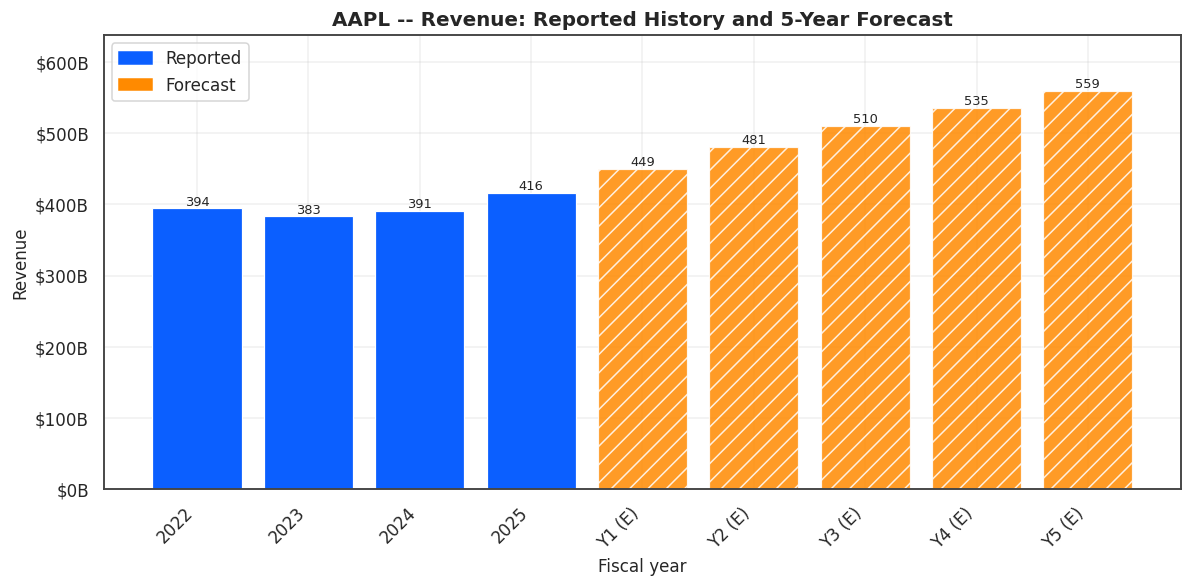

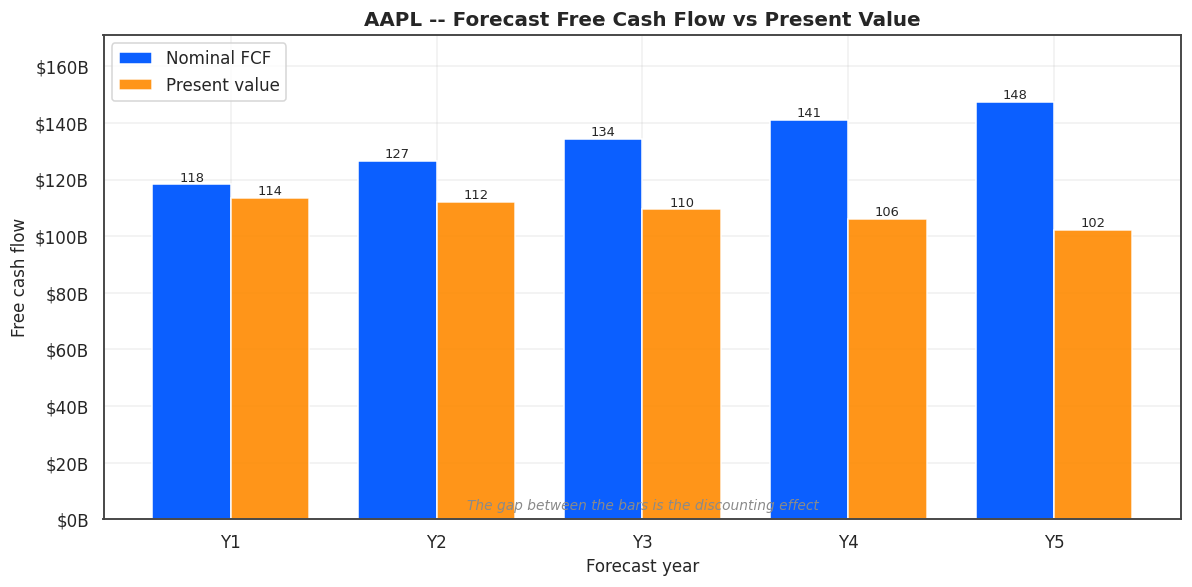

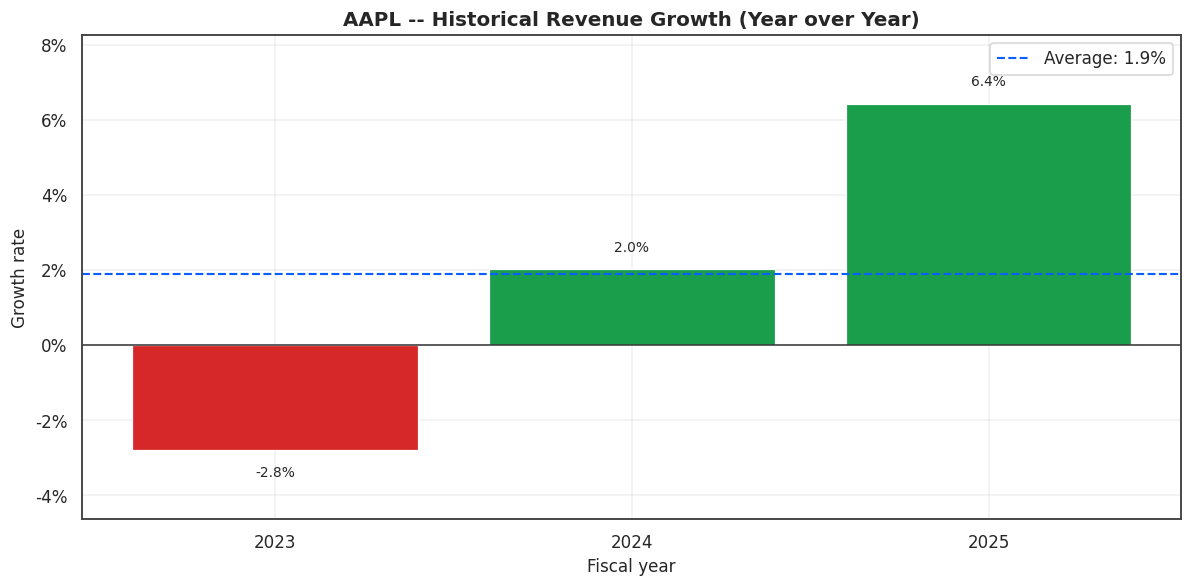

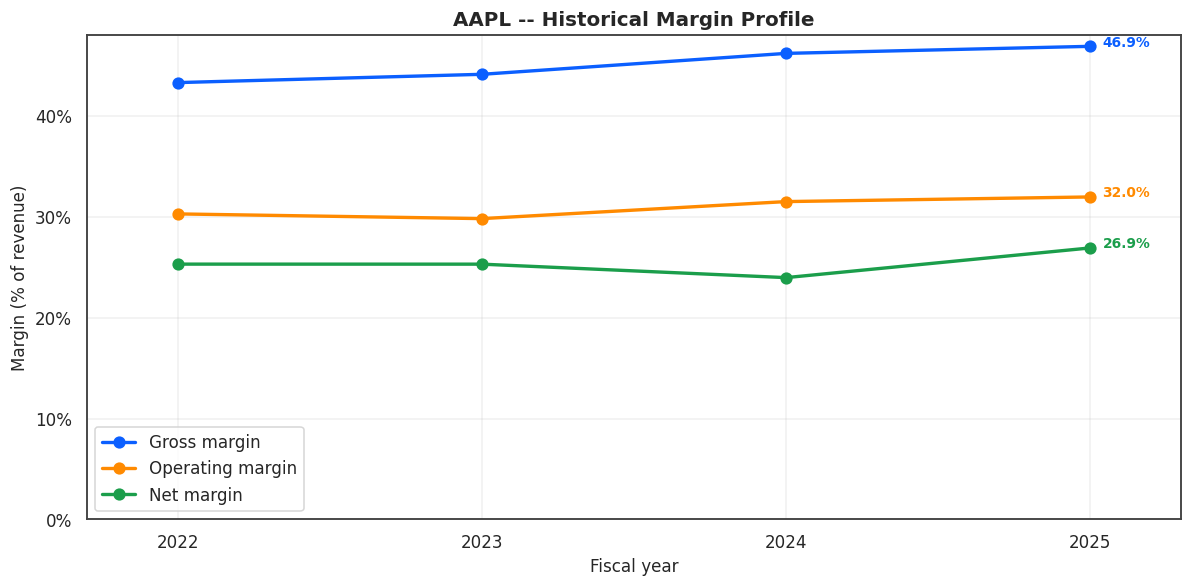

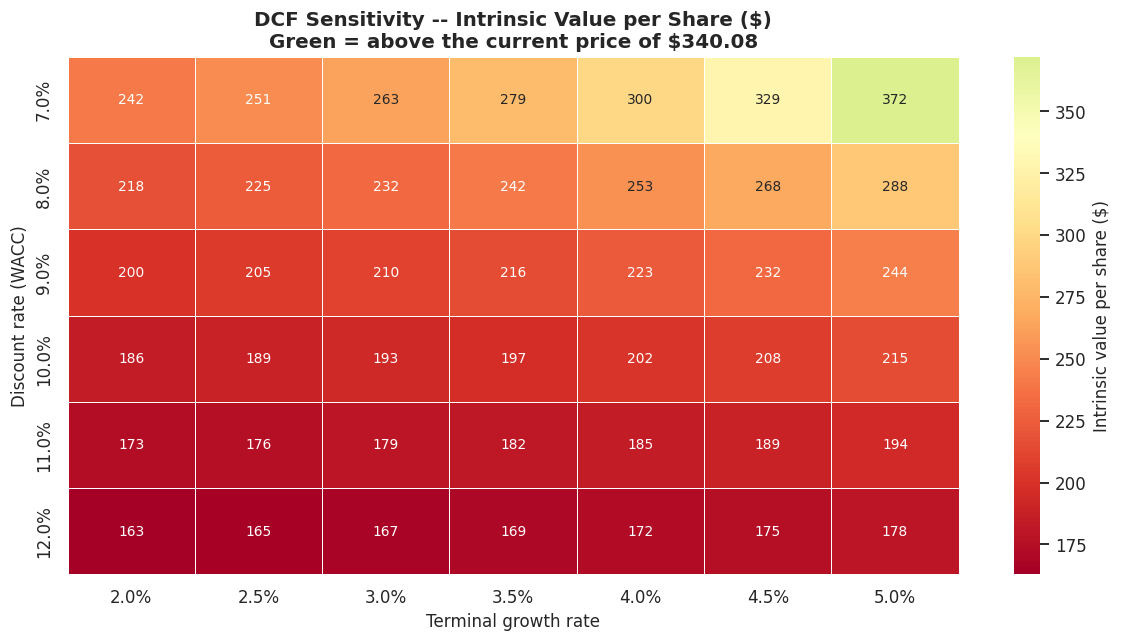

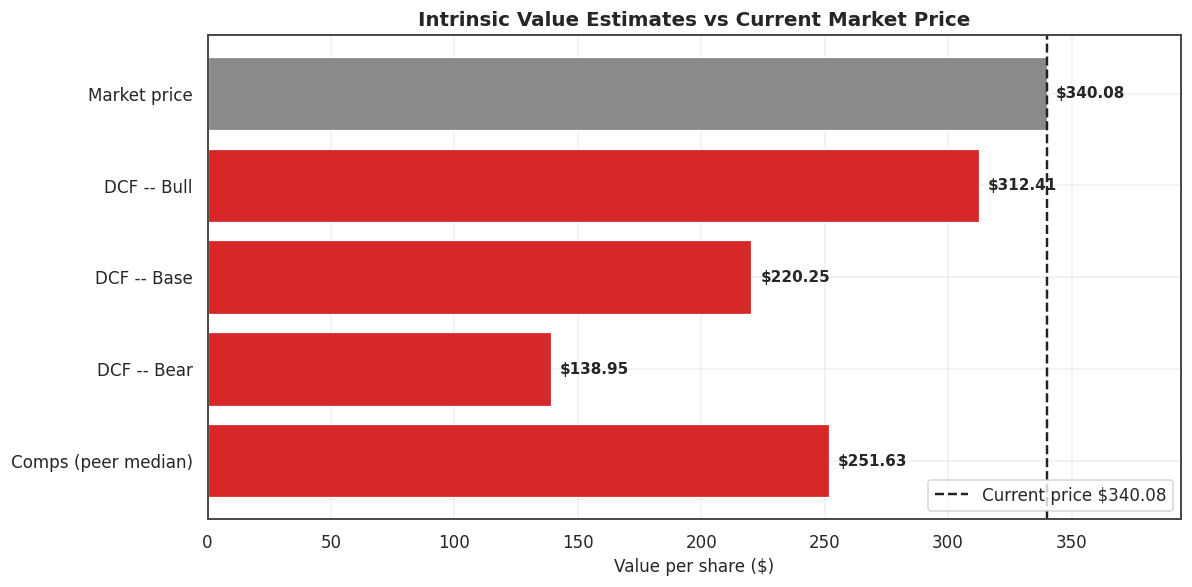

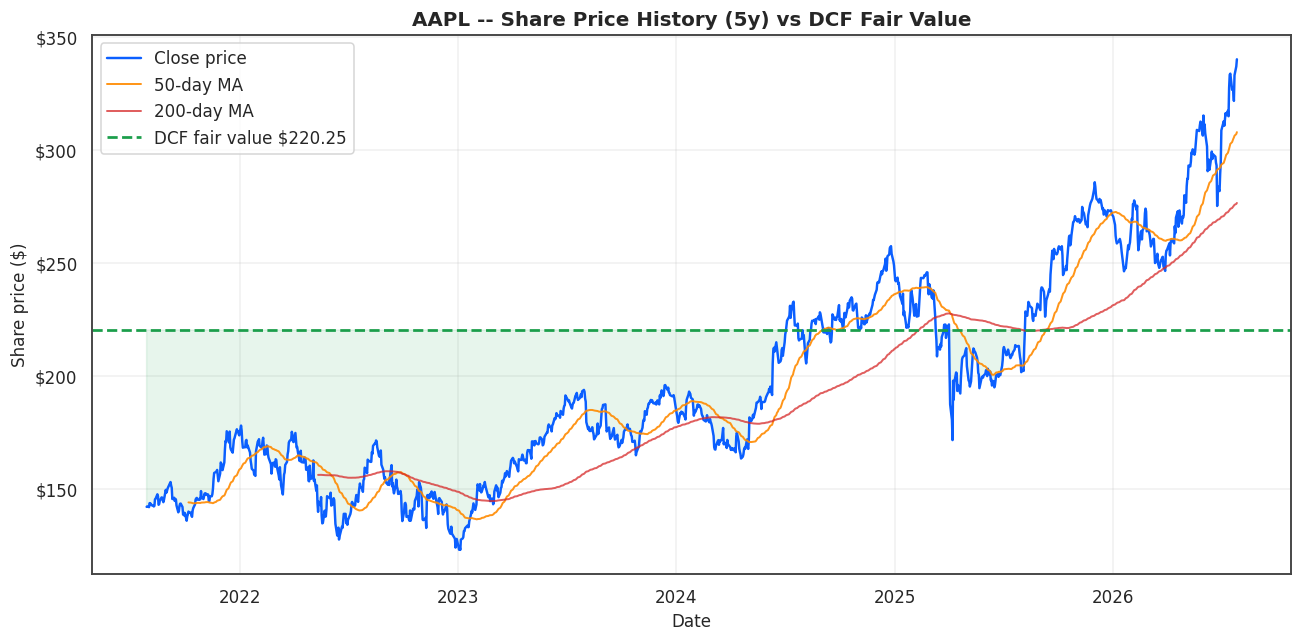


 INVESTMENT SUMMARY

--- Bull Case ------------------------------------------------------------------
   Target value: $312.41  (8.1% downside)
   Requires revenue growth near 11.0% in year one and an
   operating margin of 33.5%, discounted at 7.5%.
   The path: services and high-margin recurring revenue keep mixing up,
   an installed base of over two billion devices monetises further, and
   sustained buybacks compound per-share value on top of the operating result.

--- Base Case ------------------------------------------------------------------
   Target value: $220.25  (35.2% downside)
   Assumes growth decaying from 8.0% to 4.5%, a stable
   31.5% operating margin, and a discount rate of 8.5%.
   Of that value, 81.2% sits in the terminal
   value, i.e. in the years beyond the explicit forecast.

--- Bear Case ------------------------------------------------------------------
   Target value: $138.95  (59.1% downside)
   Assumes growth falling to 0.5%, margins compressing to 28.

In [ ]:
# =============================================================================
#  CELL 13 -- MAIN ORCHESTRATION
# =============================================================================

def print_company_snapshot(data: CompanyData) -> None:
    """One-screen overview of the company before any modelling begins."""
    banner(f"{data.name} ({data.ticker}) -- Company Snapshot")

    rows = [
        ["Current share price",   fmt_price(data.current_price)],
        ["Market capitalisation", fmt_money(data.market_cap)],
        ["Enterprise value",      fmt_money(data.enterprise_value)],
        ["Shares outstanding",    f"{data.shares_outstanding/MILLION:,.0f}M"
                                  if is_valid(data.shares_outstanding) else "n/a"],
        ["Beta",                  f"{data.beta:,.2f}" if is_valid(data.beta) else "n/a"],
        ["-- Income statement --", ""],
        ["Revenue (TTM/FY)",      fmt_money(data.revenue)],
        ["Gross profit",          fmt_money(data.gross_profit)],
        ["EBITDA",                fmt_money(data.ebitda)],
        ["Operating income",      fmt_money(data.operating_income)],
        ["Net income",            fmt_money(data.net_income)],
        ["Diluted EPS",           f"${data.eps:,.2f}" if is_valid(data.eps) else "n/a"],
        ["-- Cash flow --", ""],
        ["Operating cash flow",   fmt_money(data.operating_cash_flow)],
        ["Capital expenditure",   fmt_money(data.capex)],
        ["Free cash flow",        fmt_money(data.free_cash_flow)],
        ["-- Balance sheet --", ""],
        ["Cash and equivalents",  fmt_money(data.cash)],
        ["Total debt",            fmt_money(data.total_debt)],
        ["Net debt",              fmt_money(data.net_debt)],
        ["Total equity",          fmt_money(data.total_equity)],
        ["-- Returns and margins --", ""],
        ["Gross margin",          fmt_pct(data.gross_margin)],
        ["Operating margin",      fmt_pct(data.operating_margin)],
        ["Net margin",            fmt_pct(data.net_margin)],
        ["ROE",                   fmt_pct(data.roe)],
        ["ROIC",                  fmt_pct(data.roic)],
    ]

    print(tabulate(rows, headers=["Metric", "Value"], tablefmt="simple_outline"))

    if data.warnings_log:
        print("\n   Data quality notes:")
        for message in data.warnings_log:
            print(f"     - {message}")


def main() -> Dict:
    """
    Run the complete valuation workflow end to end.

    Returns a dict of every intermediate object so you can keep poking at the
    results in Colab after the report has printed:

        results = main()
        results["dcf"].forecast
        results["sensitivity"]
    """
    banner(f"{TICKER} Equity Valuation Model", char="#")
    print(f"   Run date : {datetime.now():%Y-%m-%d %H:%M}")
    print(f"   Subject  : {TICKER}")
    print(f"   Peer set : {', '.join(PEER_TICKERS)}")
    print(f"   Method   : 5-year unlevered DCF + trading comparables")
    print()

    # ---- STEP 1: DATA ----------------------------------------------------
    subheader("Step 1 of 8 -- Downloading market and financial data")
    data = fetch_company_data(TICKER, with_history=True)

    if not is_valid(data.revenue) or not is_valid(data.current_price):
        print("\n   FATAL: could not retrieve the minimum data needed to build a model.")
        print("   Check the ticker symbol and your network connection, then re-run.")
        return {"data": data}

    peers = [fetch_company_data(t, with_history=False) for t in PEER_TICKERS]

    # ---- STEP 2: SNAPSHOT ------------------------------------------------
    print_company_snapshot(data)

    # ---- STEP 3: DISCOUNT RATE -------------------------------------------
    subheader("Step 2 of 8 -- Establishing the discount rate")
    if AUTO_ESTIMATE_WACC:
        wacc = estimate_wacc(data)
    else:
        wacc = DISCOUNT_RATE_WACC
        print(f"   Using the user-specified WACC of {fmt_pct(wacc)}. "
              f"(Set AUTO_ESTIMATE_WACC = True to derive it from beta via CAPM.)")

    # ---- STEP 4: KPI SCORECARD -------------------------------------------
    kpis = analyze_kpis(data, wacc)
    fundamental_score = print_kpi_report(kpis)

    # ---- STEP 5: BASE-CASE DCF -------------------------------------------
    growth_rates = [
        REVENUE_GROWTH_Y1, REVENUE_GROWTH_Y2, REVENUE_GROWTH_Y3,
        REVENUE_GROWTH_Y4, REVENUE_GROWTH_Y5,
    ][:FORECAST_YEARS]

    dcf = run_dcf(
        data=data,
        growth_rates=growth_rates,
        operating_margin=OPERATING_MARGIN,
        wacc=wacc,
        terminal_growth=TERMINAL_GROWTH_RATE,
    )

    if dcf is None:
        print("\n   FATAL: the DCF could not be constructed. Review your assumptions.")
        return {"data": data, "kpis": kpis}

    print_dcf_report(dcf, data)

    # ---- STEP 6: RELATIVE VALUATION --------------------------------------
    comps = build_comparables_table(data, peers)
    implied = implied_values_from_multiples(data, comps)
    implied_avg = print_comparables_report(data, comps, implied)

    # ---- STEP 7: SENSITIVITY AND SCENARIOS -------------------------------
    print("\n[model] Building the sensitivity grid ...")
    grid = build_sensitivity_table(data, growth_rates, OPERATING_MARGIN)
    display_sensitivity_table(grid, data.current_price)

    scenarios = run_scenarios(data, growth_rates, OPERATING_MARGIN, wacc)
    print_scenario_table(scenarios, data.current_price)

    scenario_values = {
        name: (result.fair_value_per_share if result else np.nan)
        for name, result in scenarios.items()
    }

    # ---- STEP 8: CHARTS AND NARRATIVE ------------------------------------
    if SHOW_CHARTS:
        render_all_charts(data, dcf, grid, implied_avg, scenario_values)

    generate_investment_summary(data, kpis, scenarios, fundamental_score,
                                implied_avg, grid)

    print_final_verdict(data, scenarios.get("Base") or dcf, fundamental_score)

    return {
        "data": data,
        "peers": peers,
        "kpis": kpis,
        "kpi_table": kpi_dataframe(kpis),
        "dcf": dcf,
        "comparables": comps,
        "implied_values": implied,
        "sensitivity": grid,
        "scenarios": scenarios,
        "wacc": wacc,
        "fundamental_score": fundamental_score,
    }


# =============================================================================
#  ENTRY POINT
# =============================================================================
# Runs automatically when executed as a script or via %run in Colab. If you
# import this file as a module instead, nothing runs until you call main().

if __name__ == "__main__":
    results = main()